In [35]:
# Import required libraries
import re
import numpy as np
import matplotlib.pyplot as plt
import os
from collections import defaultdict
import pandas as pd

# Set plot style
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10


In [36]:
def extract_loss_from_summary(file_path):
    """Extract loss values for each equation from a summary file."""
    losses = {}
    
    if not os.path.exists(file_path):
        print(f"Warning: File {file_path} does not exist")
        return losses
    
    with open(file_path, 'r') as f:
        content = f.read()
    
    # Find all equation sections
    equation_sections = re.findall(r'GT Equation #(\d+):.*?Score: ([\d.e-]+), Loss: ([\d.e-]+)', content, re.DOTALL)
    
    for eq_num, score, loss in equation_sections:
        eq_num = int(eq_num)
        loss = float(loss)
        losses[eq_num] = loss
        print(f"Equation {eq_num}: Loss = {loss:.2e}")
    
    return losses


In [37]:
# Initialize data structure and experiment labels
exp_data = {}
base_path = "lasr_runs_synthetic_llama32"

# Define experiment labels
exp_labels = {
    'baseline': 'PySR (Baseline)',
    0: 'Llama3.2',
    1: 'Llama3.2 p',
    2: 'Llama3.2 ph',
    3: 'Llama3.2 phw',
    4: 'Qwen3-8B',
    5: 'Qwen3-8B-think',
    6: 'DeepSeek V3',
    7: 'DeepSeek R1'
}

# Define equation names and descriptions based on synthetic_equations.csv and synthetic_hints.json
equation_info = {
    1: {
        'name': 'Damped Sinusoid',
        'formula': 'sin(x)*exp(-y²/2)',
        'description': 'A damped sinusoidal function in 2D space, combining periodic and exponential decay'
    },
    2: {
        'name': '3D Euclidean Distance', 
        'formula': 'sqrt(x² + y² + z²)',
        'description': 'The Euclidean distance function in 3D space, representing the distance from origin'
    },
    3: {
        'name': 'Softplus-Lorentzian',
        'formula': 'log(1 + exp(x))/(1 + y²)',
        'description': 'A softplus function modulated by a Lorentzian function, combining smooth activation and decay'
    },
    4: {
        'name': 'Trigonometric Product',
        'formula': 'sin(x*y)*cos(z*w)',
        'description': 'A product of two trigonometric functions in 4D space, creating complex wave patterns'
    },
    5: {
        'name': '3D Gaussian PDF',
        'formula': 'exp(-(x² + y² + z²)/(2σ²))/((2π)σ²)^(3/2)',
        'description': 'A 3D Gaussian probability density function with variable standard deviation'
    },
    6: {
        'name': 'Logarithmic Spiral',
        'formula': 'x*cos(log(sqrt(x² + y²) + ε)) + y*sin(log(sqrt(x² + y²) + ε))',
        'description': 'A logarithmic spiral function combining polar coordinates with trigonometric transformations'
    },
    7: {
        'name': 'Directional Field',
        'formula': 'y/(x + ε)*exp(-(x² + y²)/4)',
        'description': 'A directional field function with exponential decay modulation in polar coordinates'
    },
    8: {
        'name': 'Hyperbolic Approximation',
        'formula': '(exp(x) - exp(-x))*(exp(y) - exp(-y))/(1 + z²)',
        'description': 'A hyperbolic approximation using exponential differences creating wave interference patterns'
    },
    9: {
        'name': 'Rational Polynomial',
        'formula': '(x³ - 2*x*y + y²)/(x² + y² + 1)',
        'description': 'A rational polynomial function with cubic numerator and quadratic denominator normalization'
    },
    10: {
        'name': 'Sigmoid Mixture',
        'formula': 'x/(1 + exp(-y)) + z/(1 + exp(y))',
        'description': 'A sigmoid-gated mixture function simulating neural network activation and inhibition patterns'
    }
}

# Extract data from all 8 LASR experiments
for exp_num in range(8):
    exp_path = f"{base_path}/exp_{exp_num}/summary.txt"
    print(f"\n{'='*50}")
    print(f"Processing {exp_labels[exp_num]} (exp_{exp_num})")
    print(f"{'='*50}")
    losses = extract_loss_from_summary(exp_path)
    exp_data[exp_num] = losses

# Extract baseline data
baseline_path = "pysr_runs_baseline_synthetic/exp_1/summary.txt"
print(f"\n{'='*50}")
print(f"Processing {exp_labels['baseline']}")
print(f"{'='*50}")
baseline_losses = extract_loss_from_summary(baseline_path)
exp_data['baseline'] = baseline_losses

# Determine which equations are present across experiments
all_equations = set()
for exp_losses in exp_data.values():
    all_equations.update(exp_losses.keys())

all_equations = sorted(list(all_equations))
print(f"\nEquations found across all experiments: {all_equations}")
print(f"Total experiments: 8 LASR + 1 Baseline = 9 experiments")



Processing Llama3.2 (exp_0)
Equation 1: Loss = 2.31e-03
Equation 2: Loss = 6.08e+05
Equation 3: Loss = 6.29e+03
Equation 4: Loss = 2.81e-03
Equation 5: Loss = 3.31e+00
Equation 6: Loss = 4.76e+04
Equation 7: Loss = 7.37e+04
Equation 8: Loss = 4.90e+04
Equation 9: Loss = 9.46e+04
Equation 10: Loss = 3.70e+03

Processing Llama3.2 p (exp_1)
Equation 1: Loss = 2.82e-03
Equation 2: Loss = 6.55e+05
Equation 3: Loss = 1.17e+03
Equation 4: Loss = 2.14e-03
Equation 5: Loss = 1.74e+00
Equation 6: Loss = 3.18e+04
Equation 7: Loss = 3.28e+04
Equation 8: Loss = 4.62e+04
Equation 9: Loss = 8.67e+04
Equation 10: Loss = 1.09e+03

Processing Llama3.2 ph (exp_2)
Equation 1: Loss = 2.46e-03
Equation 2: Loss = 3.28e+05
Equation 3: Loss = 3.20e+03
Equation 4: Loss = 2.22e-03
Equation 5: Loss = 1.20e+00
Equation 6: Loss = 3.74e+04
Equation 7: Loss = 1.14e+05
Equation 8: Loss = 1.47e+05
Equation 9: Loss = 1.37e+05
Equation 10: Loss = 3.85e+00

Processing Llama3.2 phw (exp_3)
Equation 1: Loss = 2.55e-03
Equa

In [38]:
# Create a pandas DataFrame for better visualization
summary_data = []

for eq_num in all_equations:
    eq_name = equation_info[eq_num]['name'] if eq_num in equation_info else f'Eq #{eq_num}'
    row = {'Equation': f'{eq_name} (#{eq_num})'}
    # Add baseline first
    if eq_num in exp_data['baseline']:
        row[exp_labels['baseline']] = exp_data['baseline'][eq_num]
    else:
        row[exp_labels['baseline']] = np.nan
    # Add LASR experiments
    for exp_num in range(8):
        if eq_num in exp_data[exp_num]:
            row[exp_labels[exp_num]] = exp_data[exp_num][eq_num]
        else:
            row[exp_labels[exp_num]] = np.nan
    summary_data.append(row)

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.set_index('Equation')

print("Loss Comparison Summary Table:")
print("(Baseline vs 8 LASR Experiments - Values in scientific notation)")
display(summary_df.style.format('{:.2e}', na_rep='-'))


Loss Comparison Summary Table:
(Baseline vs 8 LASR Experiments - Values in scientific notation)


,PySR (Baseline),Llama3.2,Llama3.2 p,Llama3.2 ph,Llama3.2 phw,Qwen3-8B,Qwen3-8B-think,DeepSeek V3,DeepSeek R1
Equation,,,,,,,,,
Damped Sinusoid (#1),2.54e-03,2.31e-03,2.82e-03,2.46e-03,2.55e-03,2.11e-03,2.52e-03,2.26e-03,2.44e-03
3D Euclidean Distance (#2),6.07e+05,6.08e+05,6.55e+05,3.28e+05,1.03e+05,7.39e+05,1.20e+05,6.38e+05,1.42e+05
Softplus-Lorentzian (#3),2.74e+03,6.29e+03,1.17e+03,3.20e+03,1.28e+03,6.56e+02,1.27e+03,2.14e+03,3.02e+03
Trigonometric Product (#4),1.93e+04,2.81e-03,2.14e-03,2.22e-03,2.03e+05,2.60e-03,2.63e-03,6.76e+04,2.39e-03
3D Gaussian PDF (#5),2.39e+00,3.31e+00,1.74e+00,1.20e+00,1.42e+00,1.27e+00,2.34e+00,7.10e-01,2.11e+00
Logarithmic Spiral (#6),3.96e+04,4.76e+04,3.18e+04,3.74e+04,4.52e+04,2.75e+04,9.36e+04,4.63e+04,2.30e+04
Directional Field (#7),5.05e+04,7.37e+04,3.28e+04,1.14e+05,3.37e+05,1.35e+05,4.59e+04,3.21e+04,2.66e+04
Hyperbolic Approximation (#8),9.18e+04,4.90e+04,4.62e+04,1.47e+05,2.46e+04,2.53e+05,2.93e+04,8.52e+04,4.05e+04
Rational Polynomial (#9),1.21e+05,9.46e+04,8.67e+04,1.37e+05,1.23e+05,6.36e+04,7.30e+04,1.59e+05,1.03e+05


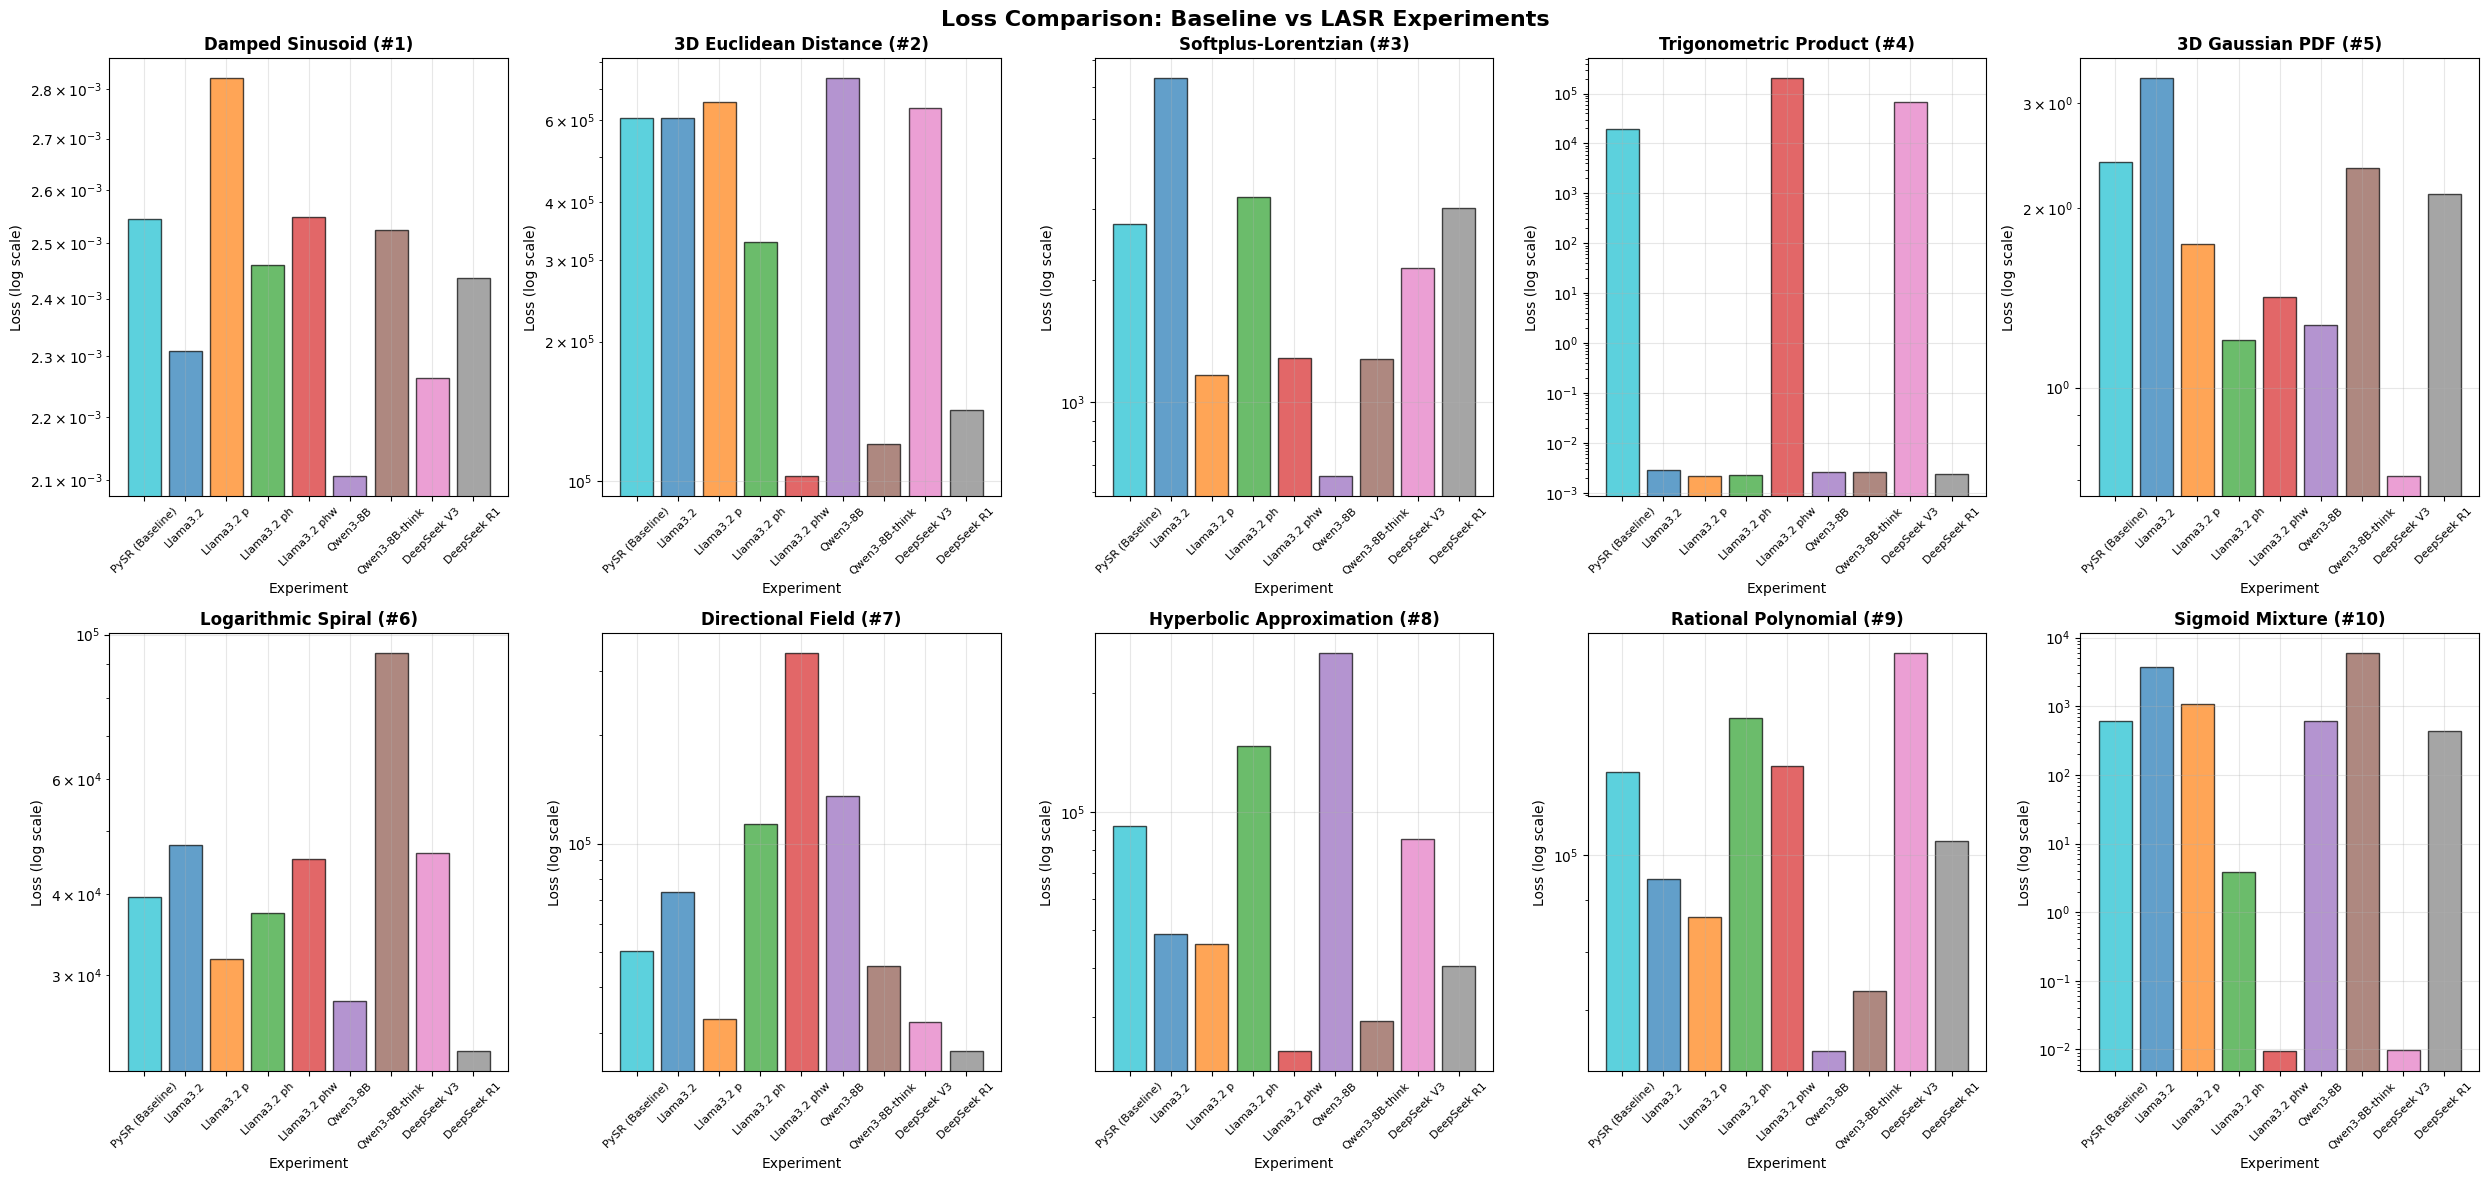

In [39]:
# Create plots
n_equations = len(all_equations)
fig, axes = plt.subplots(2, 5, figsize=(25, 12))
axes = axes.flatten()

# Include baseline + LASR experiments
all_exp_keys = ['baseline'] + list(range(8))

for i, eq_num in enumerate(all_equations):
    ax = axes[i]
    
    # Collect loss values for this equation across all experiments
    losses_for_eq = []
    exp_names = []
    colors = []
    
    for exp_key in all_exp_keys:
        if eq_num in exp_data[exp_key]:
            losses_for_eq.append(exp_data[exp_key][eq_num])
            exp_names.append(exp_labels[exp_key])
            if exp_key == 'baseline':
                colors.append('C9')  # Special color for baseline
            else:
                colors.append(f'C{exp_key}')
    
    if losses_for_eq:
        bars = ax.bar(exp_names, losses_for_eq, color=colors, alpha=0.7, edgecolor='black')
        ax.set_yscale('log')
        ax.set_xlabel('Experiment', fontsize=10)
        ax.set_ylabel('Loss (log scale)', fontsize=10)
        eq_name = equation_info[eq_num]['name'] if eq_num in equation_info else f'Eq #{eq_num}'
        ax.set_title(f'{eq_name} (#{eq_num})', fontsize=12, fontweight='bold')
        
        # Add loss values as text on bars
        for bar, loss in zip(bars, losses_for_eq):
            height = bar.get_height()
            # ax.text(bar.get_x() + bar.get_width()/2., height * 1.2,
            #        f'{loss:.1e}', ha='center', va='bottom', fontsize=7, rotation=45)
        
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='x', rotation=45, labelsize=8)
    else:
        ax.text(0.5, 0.5, 'No data', transform=ax.transAxes, 
               ha='center', va='center', fontsize=12, style='italic')
        ax.set_title(f'Equation #{eq_num} - No Data', fontsize=12)

# Hide unused subplots
for i in range(n_equations, len(axes)):
    axes[i].set_visible(False)

plt.suptitle('Loss Comparison: Baseline vs LASR Experiments', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


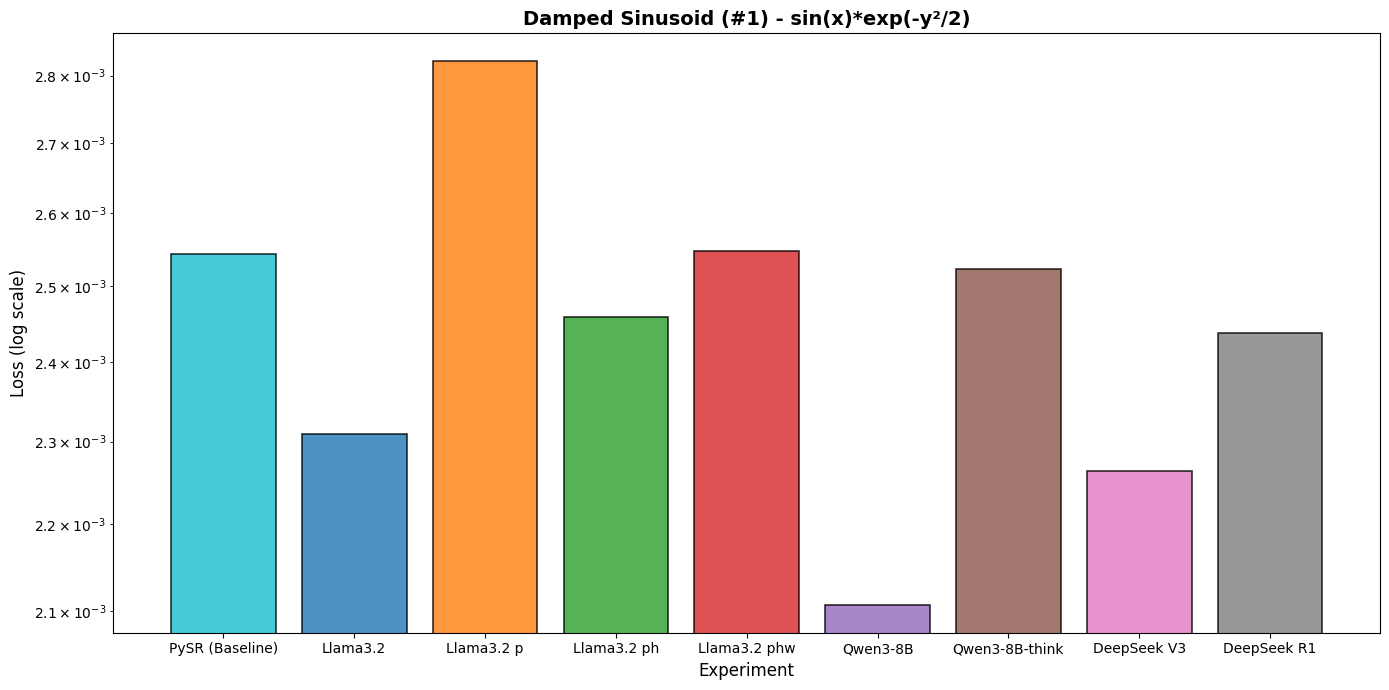


Statistics for Damped Sinusoid (#1):
  Formula: sin(x)*exp(-y²/2)
  Description: A damped sinusoidal function in 2D space, combining periodic and exponential decay
  Total experiments: 9 (1 Baseline + 8 LASR)
  Best performance: Qwen3-8B with loss 2.11e-03
  Worst performance: Llama3.2 p with loss 2.82e-03
  Loss ratio (worst/best): 1.34e+00
  LASR experiments better than baseline: 6/8
  Best LASR improvement over baseline: 1.21x better
------------------------------------------------------------


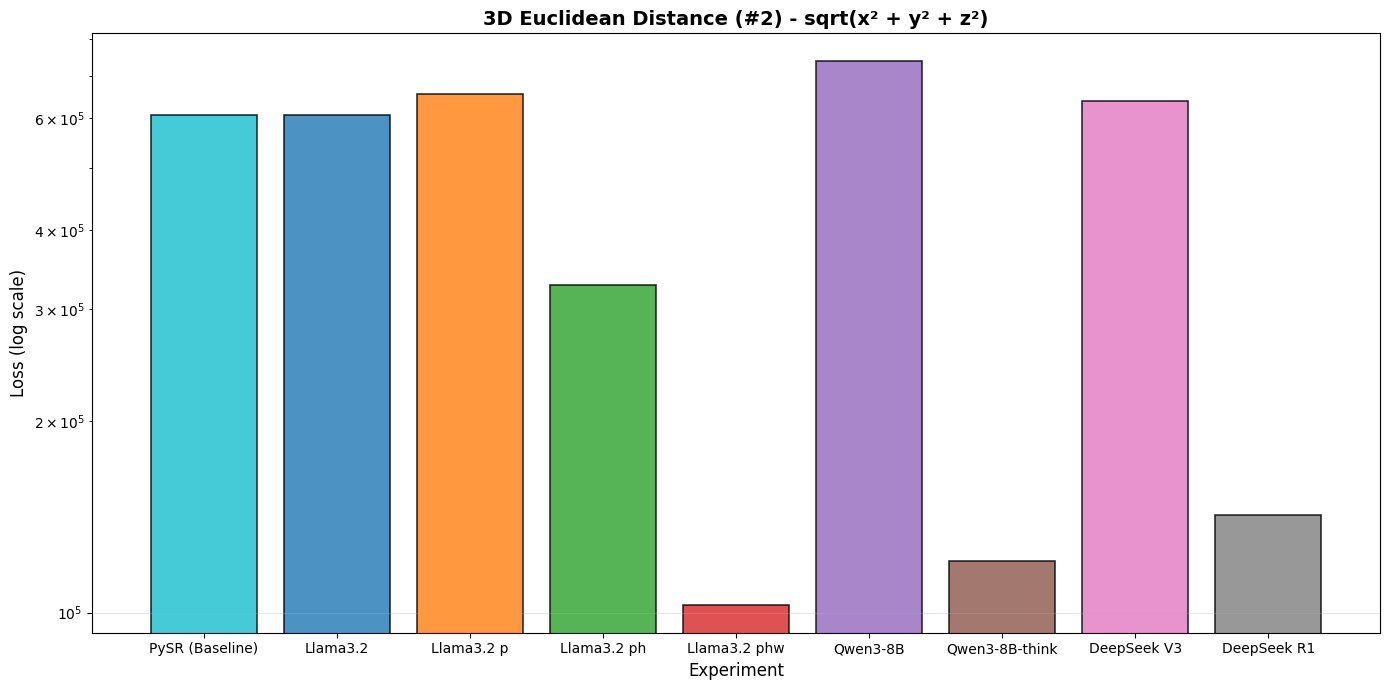


Statistics for 3D Euclidean Distance (#2):
  Formula: sqrt(x² + y² + z²)
  Description: The Euclidean distance function in 3D space, representing the distance from origin
  Total experiments: 9 (1 Baseline + 8 LASR)
  Best performance: Llama3.2 phw with loss 1.03e+05
  Worst performance: Qwen3-8B with loss 7.39e+05
  Loss ratio (worst/best): 7.20e+00
  LASR experiments better than baseline: 4/8
  Best LASR improvement over baseline: 5.92x better
------------------------------------------------------------


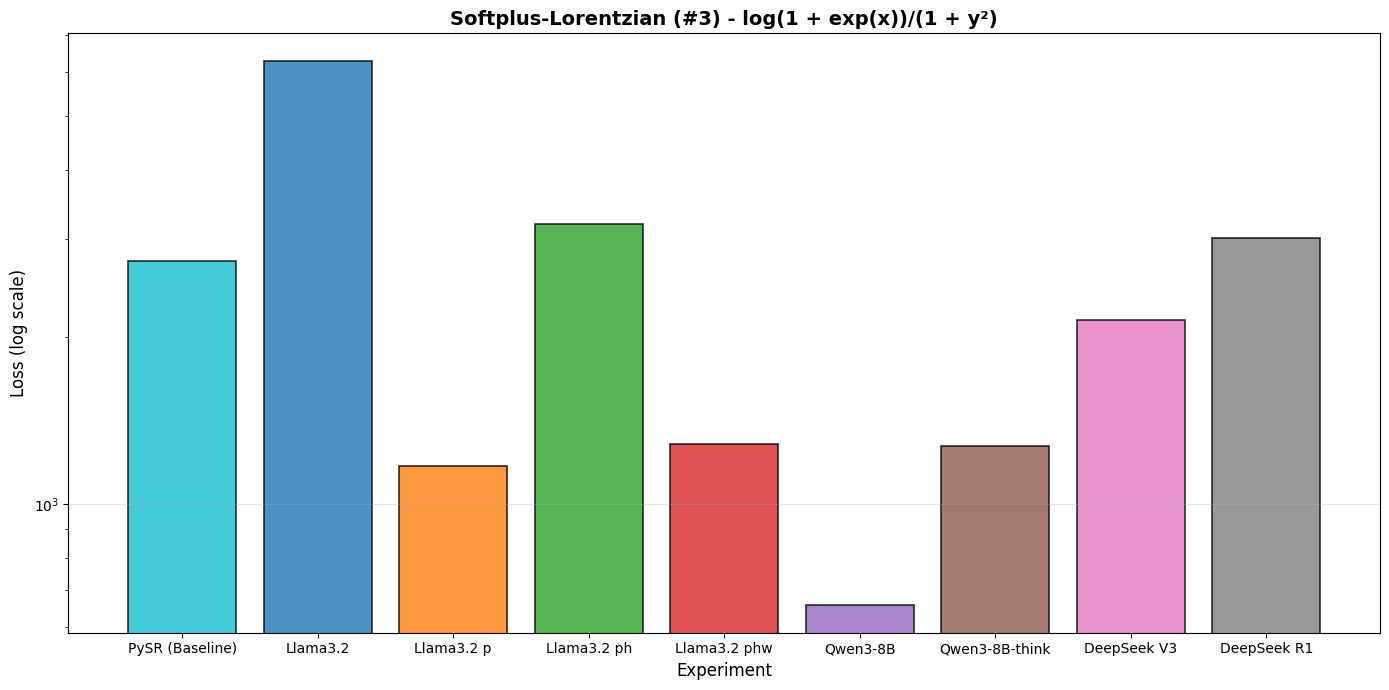


Statistics for Softplus-Lorentzian (#3):
  Formula: log(1 + exp(x))/(1 + y²)
  Description: A softplus function modulated by a Lorentzian function, combining smooth activation and decay
  Total experiments: 9 (1 Baseline + 8 LASR)
  Best performance: Qwen3-8B with loss 6.56e+02
  Worst performance: Llama3.2 with loss 6.29e+03
  Loss ratio (worst/best): 9.60e+00
  LASR experiments better than baseline: 5/8
  Best LASR improvement over baseline: 4.18x better
------------------------------------------------------------


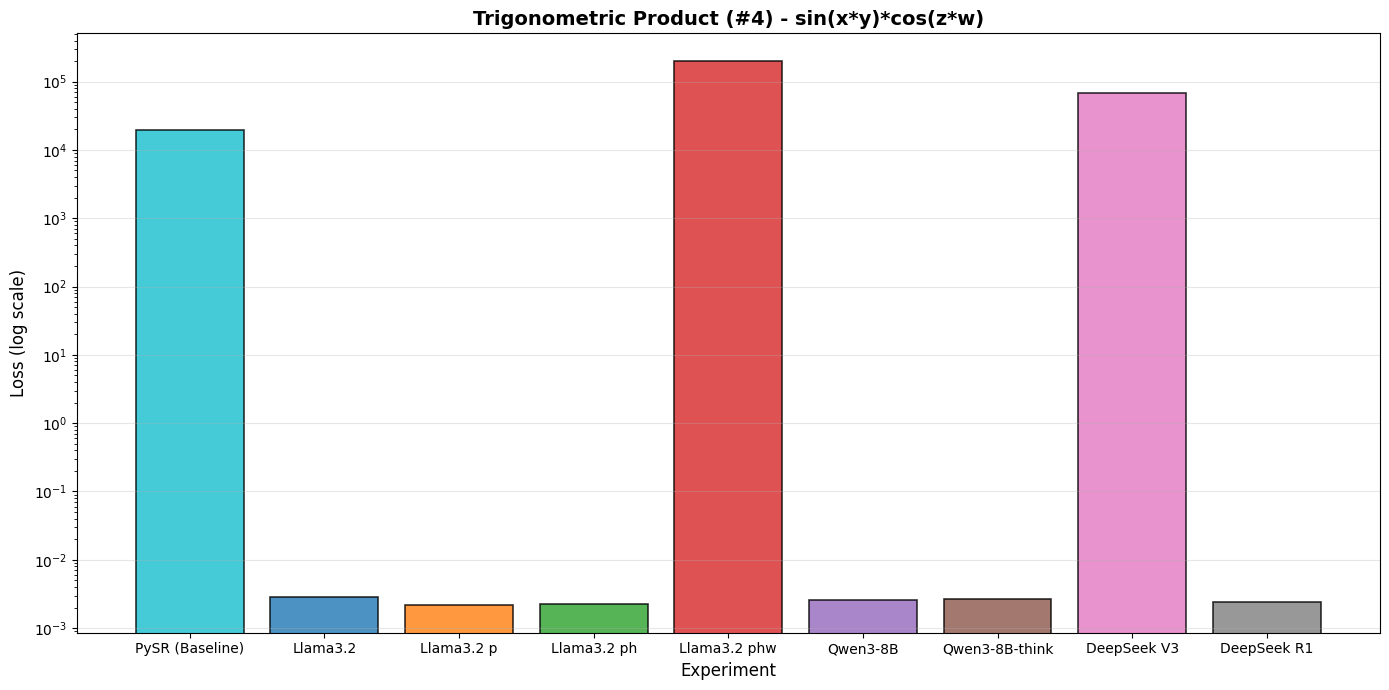


Statistics for Trigonometric Product (#4):
  Formula: sin(x*y)*cos(z*w)
  Description: A product of two trigonometric functions in 4D space, creating complex wave patterns
  Total experiments: 9 (1 Baseline + 8 LASR)
  Best performance: Llama3.2 p with loss 2.14e-03
  Worst performance: Llama3.2 phw with loss 2.03e+05
  Loss ratio (worst/best): 9.48e+07
  LASR experiments better than baseline: 6/8
  Best LASR improvement over baseline: 9022274.87x better
------------------------------------------------------------


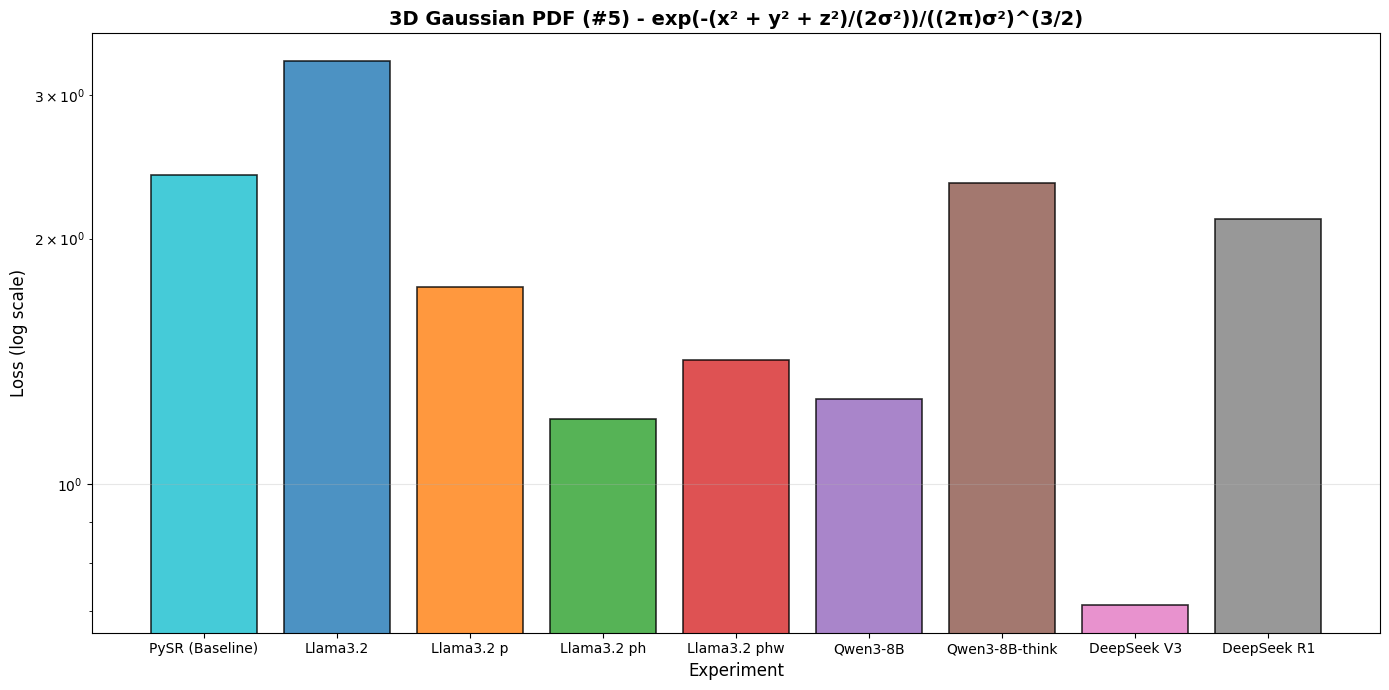


Statistics for 3D Gaussian PDF (#5):
  Formula: exp(-(x² + y² + z²)/(2σ²))/((2π)σ²)^(3/2)
  Description: A 3D Gaussian probability density function with variable standard deviation
  Total experiments: 9 (1 Baseline + 8 LASR)
  Best performance: DeepSeek V3 with loss 7.10e-01
  Worst performance: Llama3.2 with loss 3.31e+00
  Loss ratio (worst/best): 4.65e+00
  LASR experiments better than baseline: 7/8
  Best LASR improvement over baseline: 3.37x better
------------------------------------------------------------


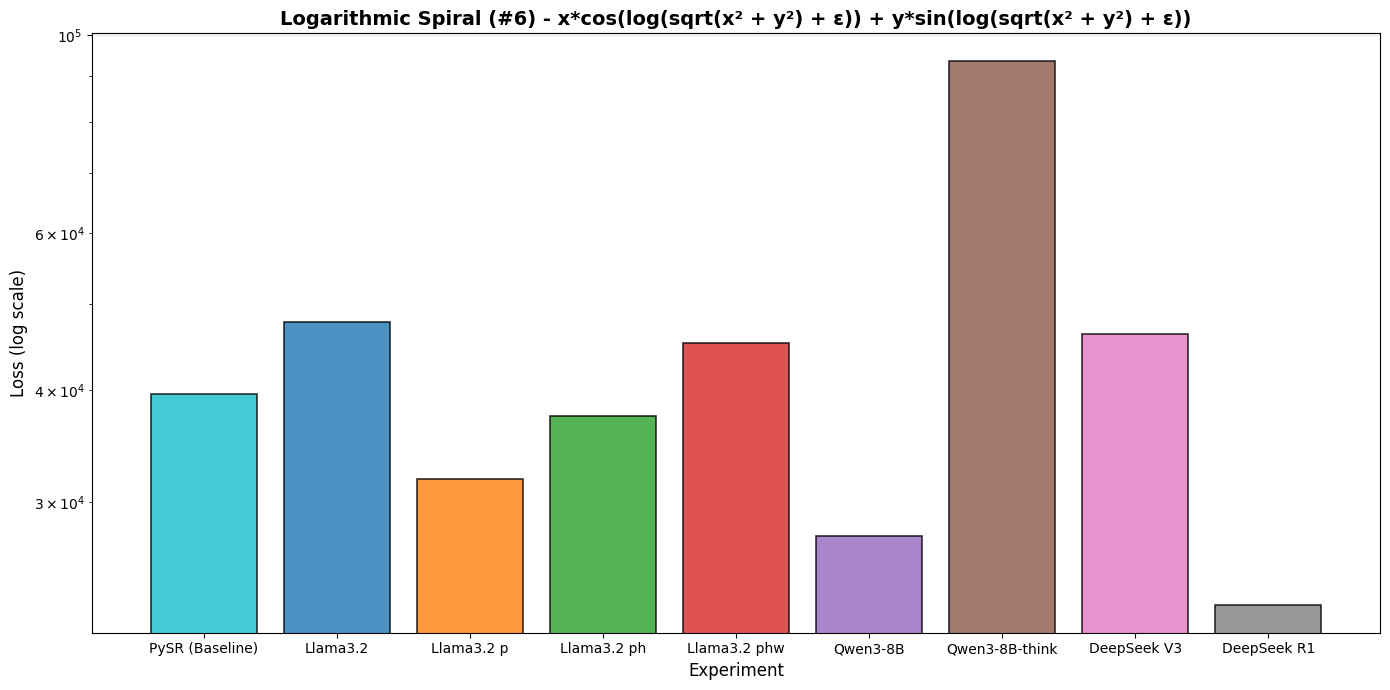


Statistics for Logarithmic Spiral (#6):
  Formula: x*cos(log(sqrt(x² + y²) + ε)) + y*sin(log(sqrt(x² + y²) + ε))
  Description: A logarithmic spiral function combining polar coordinates with trigonometric transformations
  Total experiments: 9 (1 Baseline + 8 LASR)
  Best performance: DeepSeek R1 with loss 2.30e+04
  Worst performance: Qwen3-8B-think with loss 9.36e+04
  Loss ratio (worst/best): 4.08e+00
  LASR experiments better than baseline: 4/8
  Best LASR improvement over baseline: 1.72x better
------------------------------------------------------------


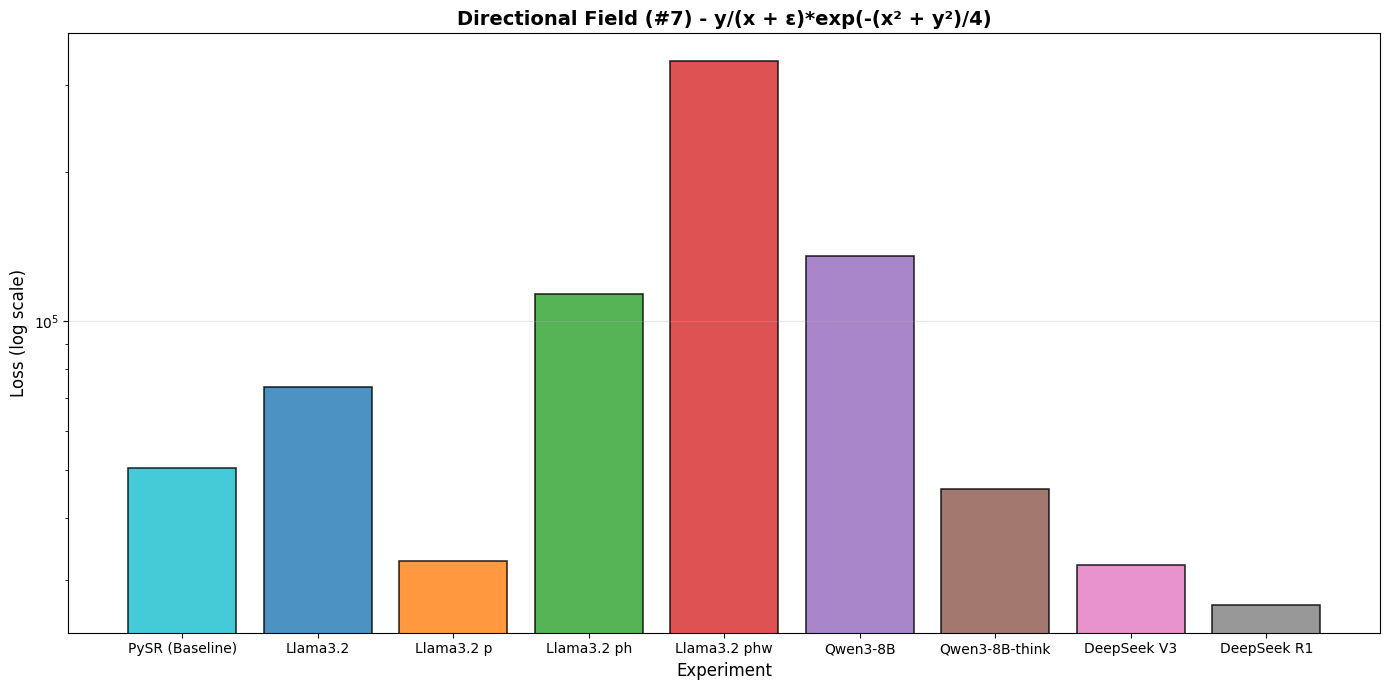


Statistics for Directional Field (#7):
  Formula: y/(x + ε)*exp(-(x² + y²)/4)
  Description: A directional field function with exponential decay modulation in polar coordinates
  Total experiments: 9 (1 Baseline + 8 LASR)
  Best performance: DeepSeek R1 with loss 2.66e+04
  Worst performance: Llama3.2 phw with loss 3.37e+05
  Loss ratio (worst/best): 1.26e+01
  LASR experiments better than baseline: 4/8
  Best LASR improvement over baseline: 1.89x better
------------------------------------------------------------


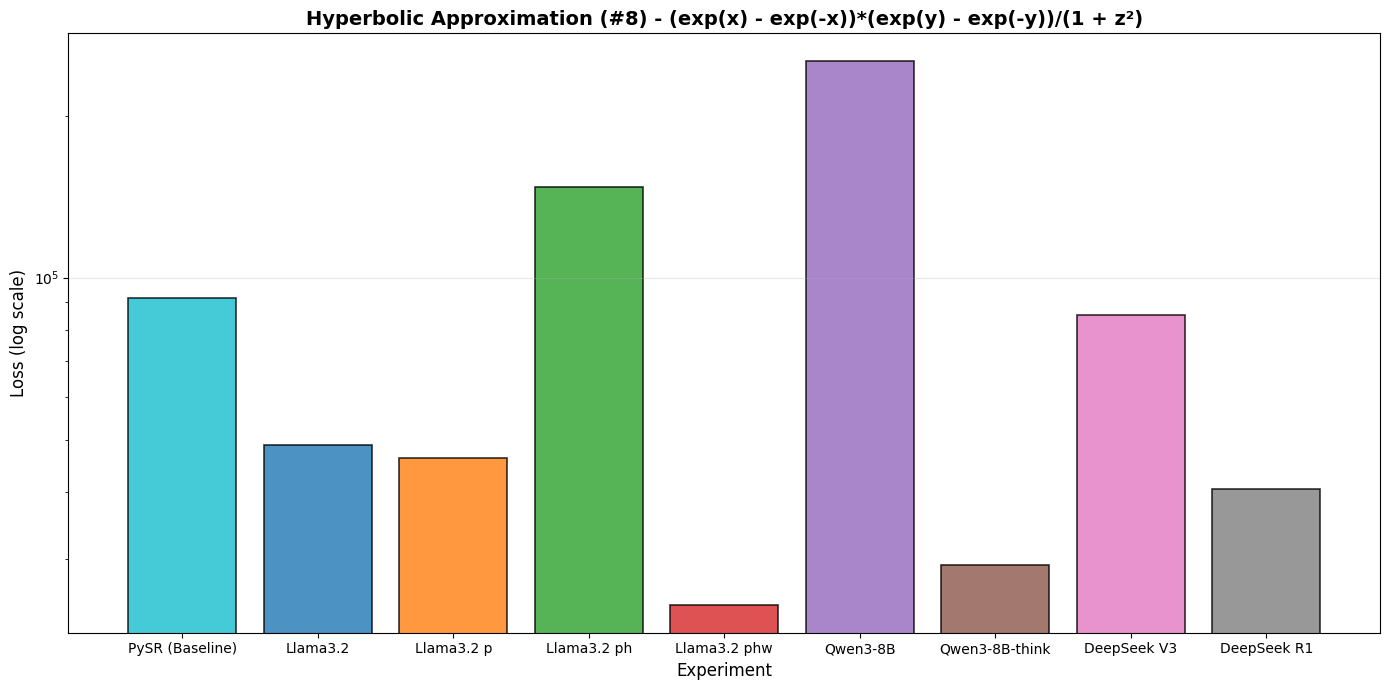


Statistics for Hyperbolic Approximation (#8):
  Formula: (exp(x) - exp(-x))*(exp(y) - exp(-y))/(1 + z²)
  Description: A hyperbolic approximation using exponential differences creating wave interference patterns
  Total experiments: 9 (1 Baseline + 8 LASR)
  Best performance: Llama3.2 phw with loss 2.46e+04
  Worst performance: Qwen3-8B with loss 2.53e+05
  Loss ratio (worst/best): 1.03e+01
  LASR experiments better than baseline: 6/8
  Best LASR improvement over baseline: 3.73x better
------------------------------------------------------------


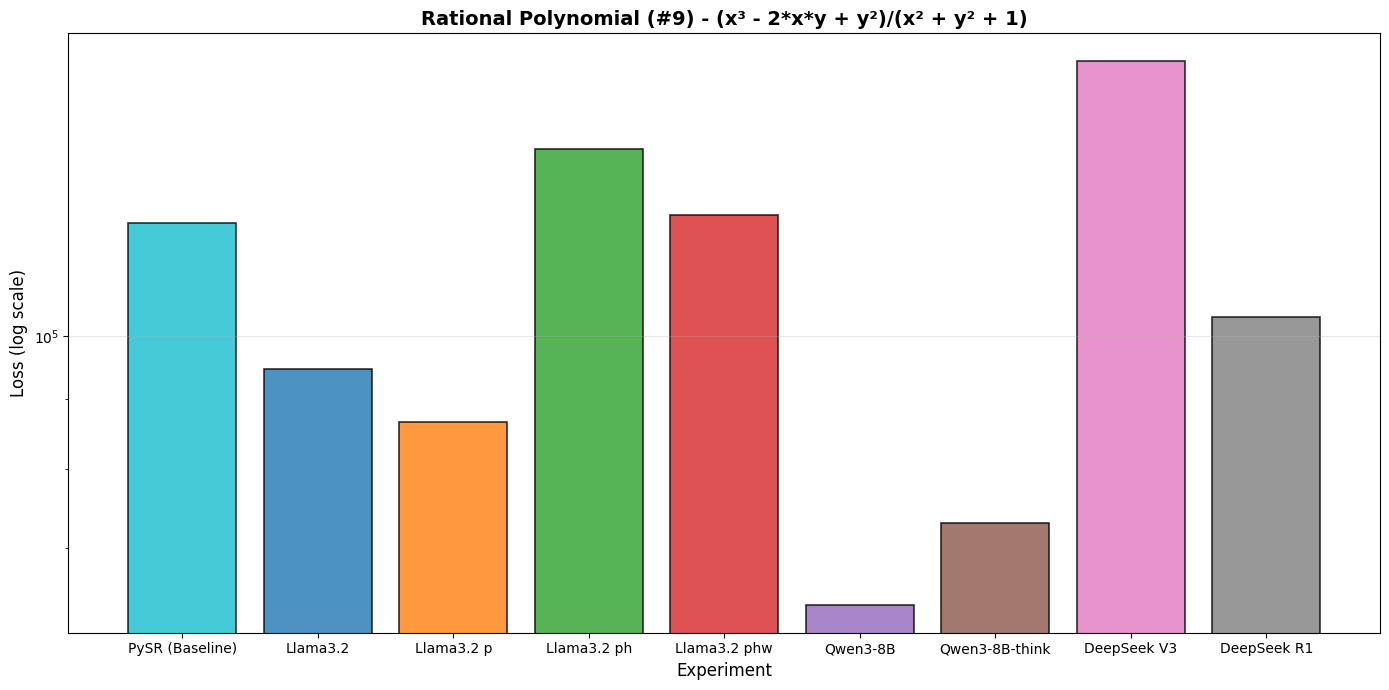


Statistics for Rational Polynomial (#9):
  Formula: (x³ - 2*x*y + y²)/(x² + y² + 1)
  Description: A rational polynomial function with cubic numerator and quadratic denominator normalization
  Total experiments: 9 (1 Baseline + 8 LASR)
  Best performance: Qwen3-8B with loss 6.36e+04
  Worst performance: DeepSeek V3 with loss 1.59e+05
  Loss ratio (worst/best): 2.50e+00
  LASR experiments better than baseline: 5/8
  Best LASR improvement over baseline: 1.90x better
------------------------------------------------------------


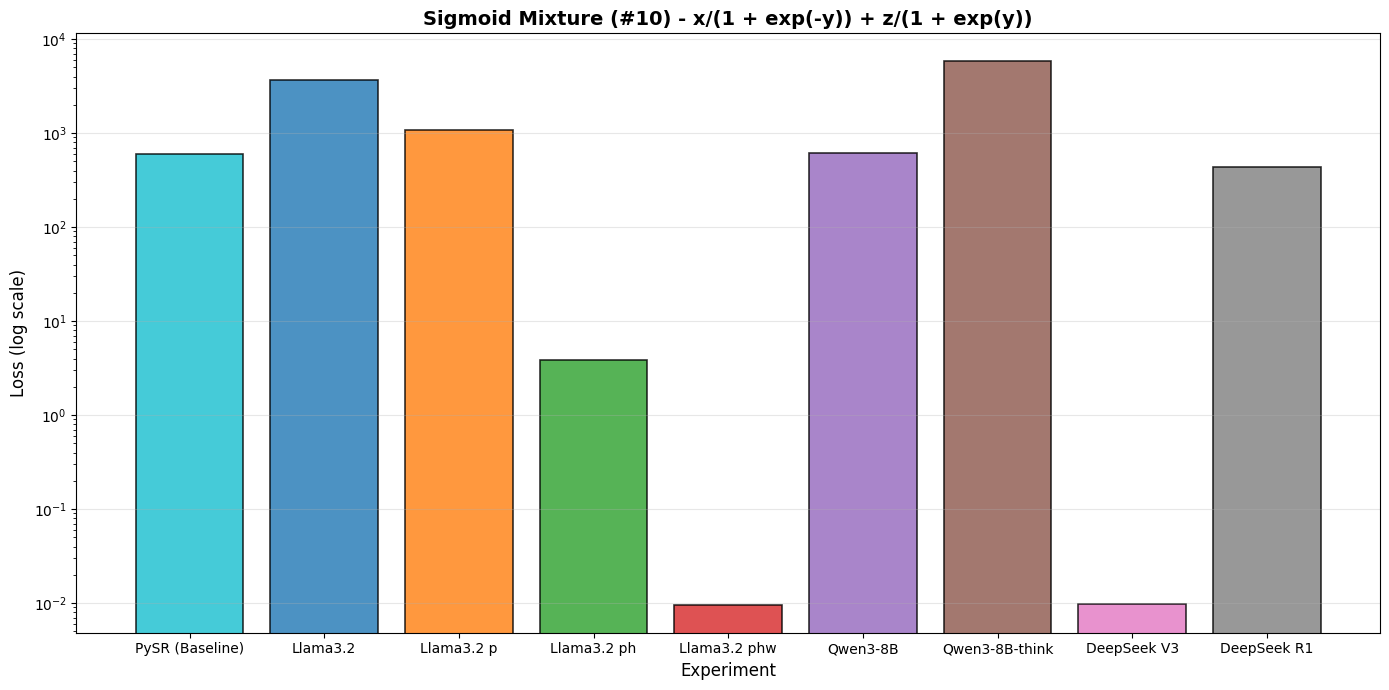


Statistics for Sigmoid Mixture (#10):
  Formula: x/(1 + exp(-y)) + z/(1 + exp(y))
  Description: A sigmoid-gated mixture function simulating neural network activation and inhibition patterns
  Total experiments: 9 (1 Baseline + 8 LASR)
  Best performance: Llama3.2 phw with loss 9.43e-03
  Worst performance: Qwen3-8B-think with loss 5.92e+03
  Loss ratio (worst/best): 6.27e+05
  LASR experiments better than baseline: 4/8
  Best LASR improvement over baseline: 64172.73x better
------------------------------------------------------------


In [40]:
# Create individual plots for each equation
for eq_num in all_equations:
    plt.figure(figsize=(14, 7))
    
    losses_for_eq = []
    exp_names = []
    colors = []
    
    for exp_key in all_exp_keys:
        if eq_num in exp_data[exp_key]:
            losses_for_eq.append(exp_data[exp_key][eq_num])
            exp_names.append(exp_labels[exp_key])
            if exp_key == 'baseline':
                colors.append('C9')  # Special color for baseline
            else:
                colors.append(f'C{exp_key}')
    
    if losses_for_eq:
        bars = plt.bar(exp_names, losses_for_eq, color=colors, alpha=0.8, 
                      edgecolor='black', linewidth=1.2)
        plt.yscale('log')
        plt.xlabel('Experiment', fontsize=12)
        plt.ylabel('Loss (log scale)', fontsize=12)
        eq_name = equation_info[eq_num]['name'] if eq_num in equation_info else f'Eq #{eq_num}'
        plt.title(f'{eq_name} (#{eq_num}) - {equation_info[eq_num]["formula"] if eq_num in equation_info else ""}', fontsize=14, fontweight='bold')
        plt.grid(True, alpha=0.3, axis='y')
        
        # Find best and worst performing experiments
        min_loss_idx = np.argmin(losses_for_eq)
        max_loss_idx = np.argmax(losses_for_eq)
        
        # Highlight best and worst - keep original colors but change border
        # bars[min_loss_idx].set_edgecolor('green')
        # bars[min_loss_idx].set_linewidth(3)
        # bars[max_loss_idx].set_edgecolor('red')
        # bars[max_loss_idx].set_linewidth(3)
        
        # Add loss values as text on bars
        # for bar, loss in zip(bars, losses_for_eq):
        #     height = bar.get_height()
        #     plt.text(bar.get_x() + bar.get_width()/2., height * 1.15,
        #             f'{loss:.2e}', ha='center', va='bottom', fontsize=10, 
        #             fontweight='bold', rotation=45)
        
        # Add legend
        # plt.figtext(0.02, 0.02, f'Best: {exp_names[min_loss_idx]} (Loss: {losses_for_eq[min_loss_idx]:.2e})', 
        #            fontsize=10, color='green', fontweight='bold')
        # plt.figtext(0.02, 0.06, f'Worst: {exp_names[max_loss_idx]} (Loss: {losses_for_eq[max_loss_idx]:.2e})', 
        #            fontsize=10, color='red', fontweight='bold')
        
        # Compare against baseline if baseline exists for this equation
        if eq_num in exp_data['baseline']:
            baseline_loss = exp_data['baseline'][eq_num]
            baseline_idx = exp_names.index(exp_labels['baseline'])
            
            # Count how many LASR experiments beat the baseline
            better_than_baseline = sum(1 for i, loss in enumerate(losses_for_eq) 
                                     if i != baseline_idx and loss < baseline_loss)
            total_lasr = len(losses_for_eq) - 1  # -1 for baseline
            
            # plt.figtext(0.02, 0.10, f'LASR better than baseline: {better_than_baseline}/{total_lasr}', 
            #            fontsize=10, color='blue', fontweight='bold')
        
        plt.tight_layout()
        plt.show()
        
        # Print statistics
        eq_name = equation_info[eq_num]['name'] if eq_num in equation_info else f'Eq #{eq_num}'
        print(f"\nStatistics for {eq_name} (#{eq_num}):")
        if eq_num in equation_info:
            print(f"  Formula: {equation_info[eq_num]['formula']}")
            print(f"  Description: {equation_info[eq_num]['description']}")
        print(f"  Total experiments: {len(losses_for_eq)} (1 Baseline + {len(losses_for_eq)-1} LASR)")
        print(f"  Best performance: {exp_names[min_loss_idx]} with loss {losses_for_eq[min_loss_idx]:.2e}")
        print(f"  Worst performance: {exp_names[max_loss_idx]} with loss {losses_for_eq[max_loss_idx]:.2e}")
        print(f"  Loss ratio (worst/best): {losses_for_eq[max_loss_idx]/losses_for_eq[min_loss_idx]:.2e}")
        
        if eq_num in exp_data['baseline']:
            baseline_loss = exp_data['baseline'][eq_num]
            better_than_baseline = sum(1 for i, loss in enumerate(losses_for_eq) 
                                     if i != baseline_idx and loss < baseline_loss)
            total_lasr = len(losses_for_eq) - 1
            print(f"  LASR experiments better than baseline: {better_than_baseline}/{total_lasr}")
            if baseline_idx != min_loss_idx:
                improvement = baseline_loss / losses_for_eq[min_loss_idx]
                print(f"  Best LASR improvement over baseline: {improvement:.2f}x better")
        
        print("-" * 60)


In [41]:
# Summary Analysis
print("="*80)
print("OVERALL SUMMARY ANALYSIS - BASELINE vs LASR")
print("="*80)

# Count wins for each experiment (including baseline)
win_counts = {'baseline': 0}
win_counts.update({i: 0 for i in range(8)})
total_comparisons = 0

for eq_num in all_equations:
    # Find experiments that have data for this equation
    valid_experiments = []
    valid_losses = []
    
    for exp_key in all_exp_keys:
        if eq_num in exp_data[exp_key]:
            valid_experiments.append(exp_key)
            valid_losses.append(exp_data[exp_key][eq_num])
    
    if valid_losses:
        best_exp_idx = np.argmin(valid_losses)
        best_exp = valid_experiments[best_exp_idx]
        win_counts[best_exp] += 1
        total_comparisons += 1

print(f"\nExperiment Win Count (out of {total_comparisons} equations):")
print(f"  {exp_labels['baseline']}: {win_counts['baseline']} wins ({(win_counts['baseline'] / total_comparisons) * 100:.1f}%)")
for exp_num in range(8):
    wins = win_counts[exp_num]
    win_percentage = (wins / total_comparisons) * 100 if total_comparisons > 0 else 0
    print(f"  {exp_labels[exp_num]}: {wins} wins ({win_percentage:.1f}%)")

# Find overall best and worst performers
all_wins = [(exp, wins) for exp, wins in win_counts.items()]
best_overall = max(all_wins, key=lambda x: x[1])
worst_overall = min(all_wins, key=lambda x: x[1])

print(f"\nBest overall performer: {best_overall[0]} with {best_overall[1]} wins")
print(f"Worst overall performer: {worst_overall[0]} with {worst_overall[1]} wins")

# LASR vs Baseline comparison
lasr_wins = sum(win_counts[i] for i in range(8))
baseline_wins = win_counts['baseline']
print(f"\nLASR vs Baseline:")
print(f"  LASR total wins: {lasr_wins}/{total_comparisons} ({(lasr_wins/total_comparisons)*100:.1f}%)")
print(f"  Baseline wins: {baseline_wins}/{total_comparisons} ({(baseline_wins/total_comparisons)*100:.1f}%)")

# Show average loss per experiment (where available)
print(f"\nAverage Loss by Experiment:")
baseline_losses = list(exp_data['baseline'].values())
if baseline_losses:
    avg_loss = np.mean(baseline_losses)
    print(f"  Baseline: {avg_loss:.2e} (across {len(baseline_losses)} equations)")

for exp_num in range(8):
    losses = list(exp_data[exp_num].values())
    if losses:
        avg_loss = np.mean(losses)
        print(f"  LASR Exp {exp_num}: {avg_loss:.2e} (across {len(losses)} equations)")

# Count equations where LASR beats baseline
baseline_comparison = {}
for eq_num in all_equations:
    if eq_num in exp_data['baseline']:
        baseline_loss = exp_data['baseline'][eq_num]
        lasr_better = []
        for exp_num in range(8):
            if eq_num in exp_data[exp_num]:
                if exp_data[exp_num][eq_num] < baseline_loss:
                    lasr_better.append(exp_num)
        baseline_comparison[eq_num] = lasr_better

print(f"\nEquations where LASR outperforms Baseline:")
total_lasr_improvements = 0
total_possible_improvements = 0

for eq_num, better_exps in baseline_comparison.items():
    total_lasr_improvements += len(better_exps)
    # Count how many LASR experiments had data for this equation
    lasr_with_data = sum(1 for exp_num in range(8) if eq_num in exp_data[exp_num])
    total_possible_improvements += lasr_with_data
    print(f"  Equation #{eq_num}: {len(better_exps)} out of {lasr_with_data} LASR experiments beat baseline")

improvement_rate = (total_lasr_improvements / total_possible_improvements) * 100 if total_possible_improvements > 0 else 0
print(f"\nOverall LASR improvement rate: {total_lasr_improvements}/{total_possible_improvements} ({improvement_rate:.1f}%) individual experiment-equation pairs beat baseline")

# Show equation coverage
print(f"\nEquation coverage:")
baseline_equations = sorted(exp_data['baseline'].keys()) if exp_data['baseline'] else []
print(f"  Baseline: {len(baseline_equations)} equations {baseline_equations}")
for exp_num in range(8):
    equations = sorted(exp_data[exp_num].keys()) if exp_data[exp_num] else []
    print(f"  LASR Exp {exp_num}: {len(equations)} equations {equations}")

print("="*80)


OVERALL SUMMARY ANALYSIS - BASELINE vs LASR

Experiment Win Count (out of 10 equations):
  PySR (Baseline): 0 wins (0.0%)
  Llama3.2: 0 wins (0.0%)
  Llama3.2 p: 1 wins (10.0%)
  Llama3.2 ph: 0 wins (0.0%)
  Llama3.2 phw: 3 wins (30.0%)
  Qwen3-8B: 3 wins (30.0%)
  Qwen3-8B-think: 0 wins (0.0%)
  DeepSeek V3: 1 wins (10.0%)
  DeepSeek R1: 2 wins (20.0%)

Best overall performer: 3 with 3 wins
Worst overall performer: baseline with 0 wins

LASR vs Baseline:
  LASR total wins: 10/10 (100.0%)
  Baseline wins: 0/10 (0.0%)

Average Loss by Experiment:
  Baseline: 9.33e+04 (across 10 equations)
  LASR Exp 0: 8.83e+04 (across 10 equations)
  LASR Exp 1: 8.55e+04 (across 10 equations)
  LASR Exp 2: 7.66e+04 (across 10 equations)
  LASR Exp 3: 8.36e+04 (across 10 equations)
  LASR Exp 4: 1.22e+05 (across 10 equations)
  LASR Exp 5: 3.69e+04 (across 10 equations)
  LASR Exp 6: 1.03e+05 (across 10 equations)
  LASR Exp 7: 3.39e+04 (across 10 equations)

Equations where LASR outperforms Baseline:
 

BASIC SETTINGS EXPLORATION


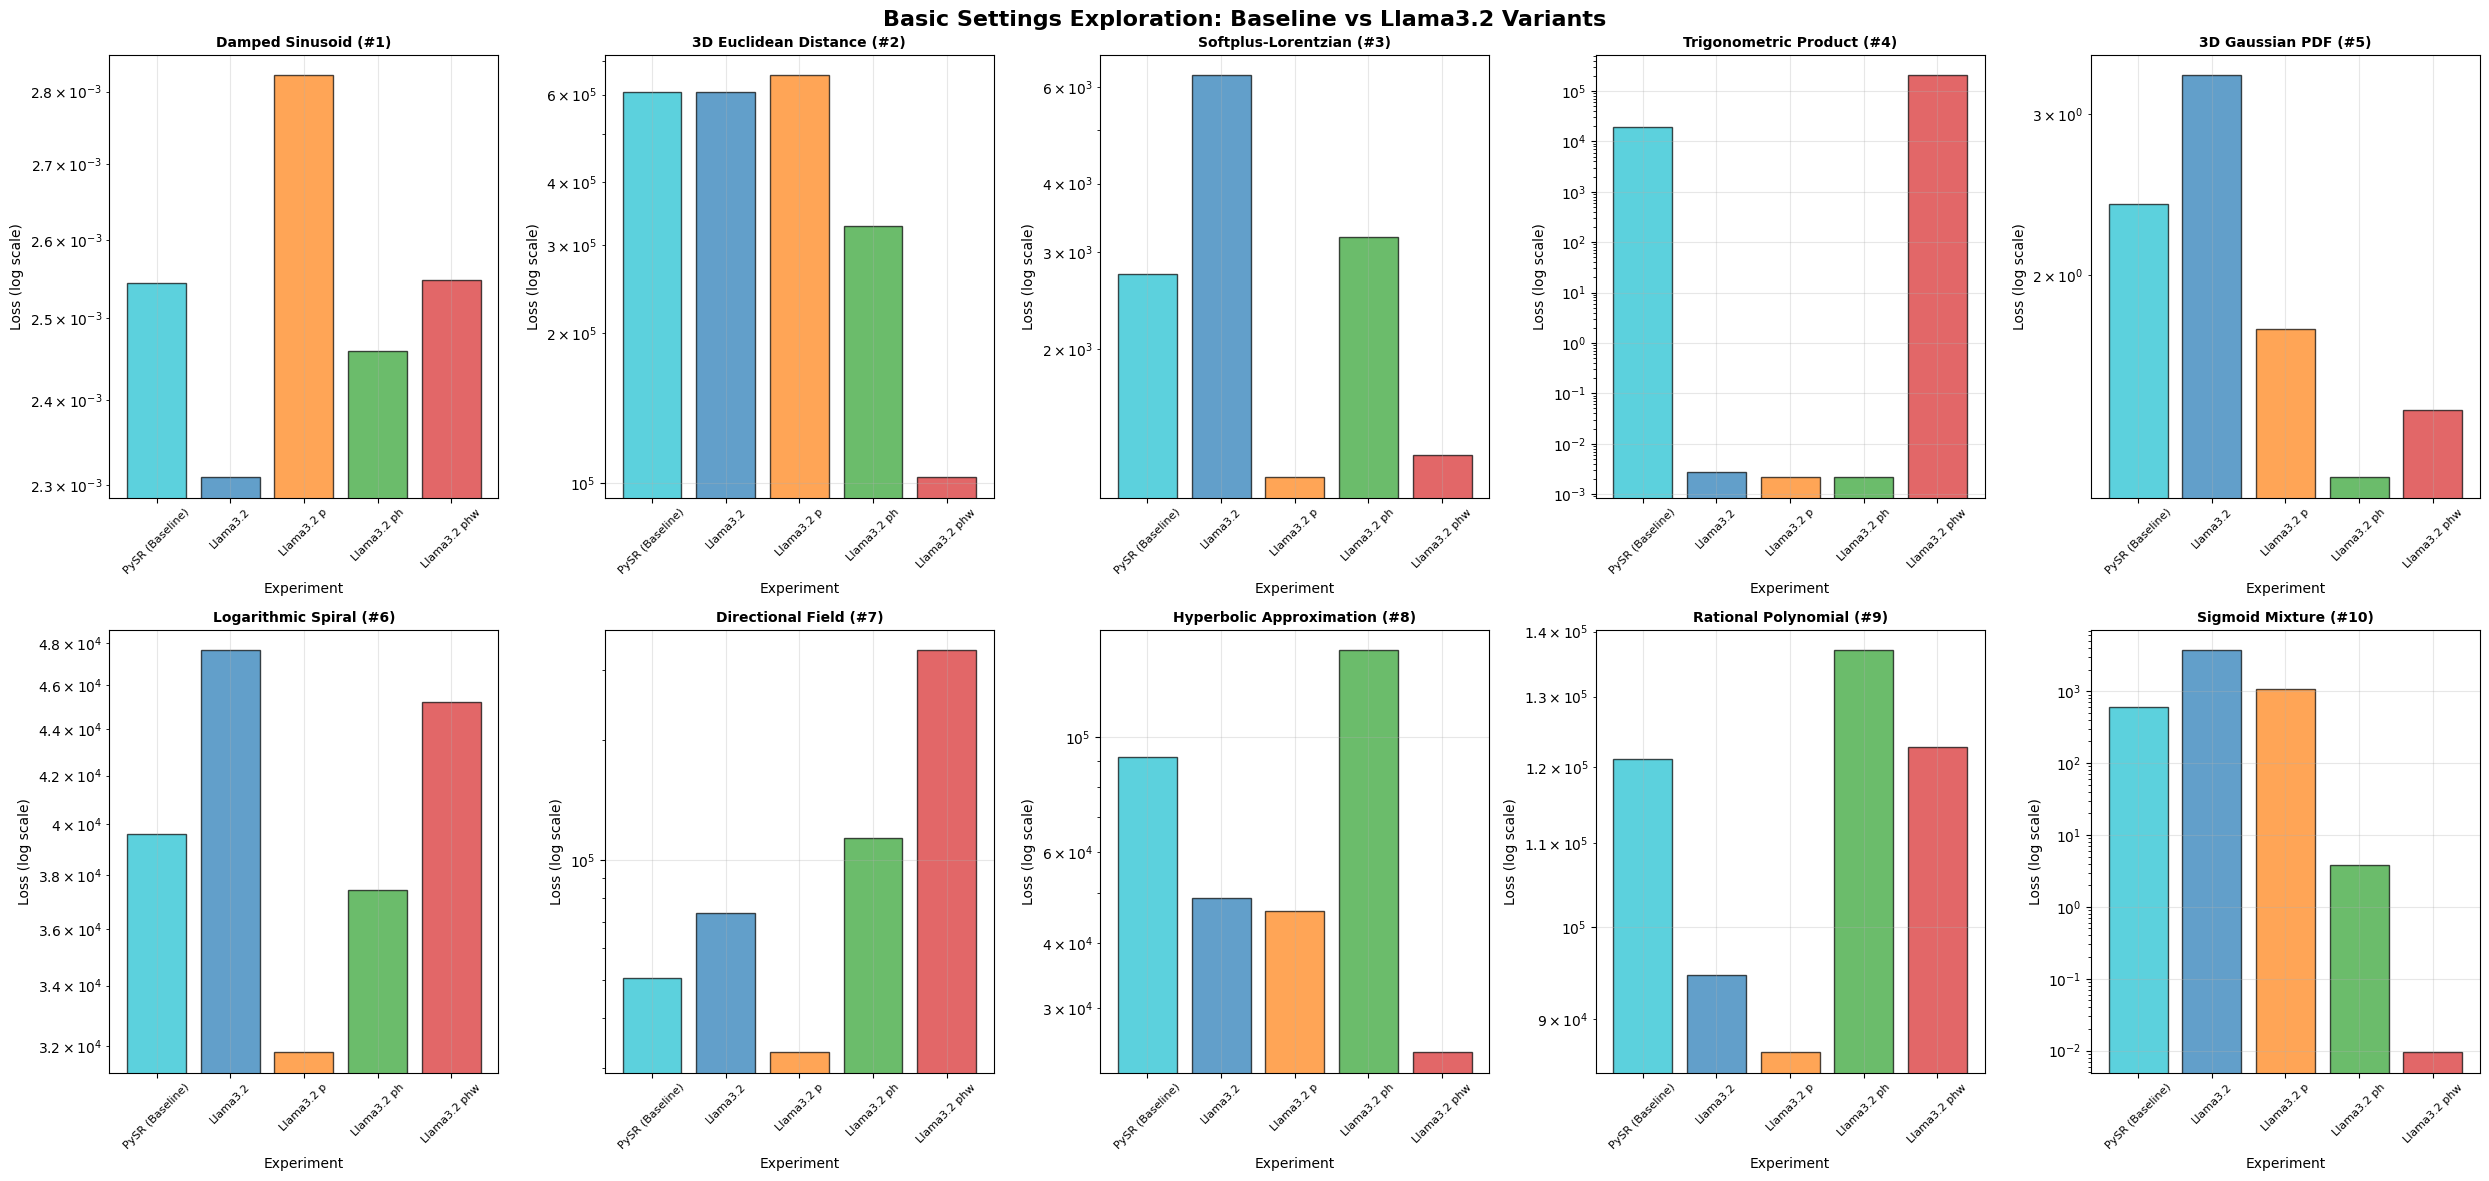


Basic Settings Win Count:
  PySR (Baseline): 0 wins (0.0%)
  Llama3.2: 1 wins (10.0%)
  Llama3.2 p: 5 wins (50.0%)
  Llama3.2 ph: 1 wins (10.0%)
  Llama3.2 phw: 3 wins (30.0%)


In [42]:
# 1. Basic Settings Exploration
basic_exp_keys = ['baseline', 0, 1, 2, 3]

print("="*80)
print("BASIC SETTINGS EXPLORATION")
print("="*80)

# Create plots for basic settings
n_equations = len(all_equations)
fig, axes = plt.subplots(2, 5, figsize=(25, 12))
axes = axes.flatten()

for i, eq_num in enumerate(all_equations):
    ax = axes[i]
    
    # Collect loss values for this equation across basic experiments
    losses_for_eq = []
    exp_names = []
    colors = []
    
    for exp_key in basic_exp_keys:
        if eq_num in exp_data[exp_key]:
            losses_for_eq.append(exp_data[exp_key][eq_num])
            exp_names.append(exp_labels[exp_key])
            if exp_key == 'baseline':
                colors.append('C9')  # Special color for baseline
            else:
                colors.append(f'C{exp_key}')
    
    if losses_for_eq:
        bars = ax.bar(exp_names, losses_for_eq, color=colors, alpha=0.7, edgecolor='black')
        
        # Highlight best and worst performers
        if len(losses_for_eq) > 1:
            min_loss_idx = np.argmin(losses_for_eq)
            max_loss_idx = np.argmax(losses_for_eq)
            # bars[min_loss_idx].set_color('green')
            # bars[min_loss_idx].set_alpha(1.0)
            # bars[max_loss_idx].set_color('red')
            # bars[max_loss_idx].set_alpha(1.0)
        
        ax.set_yscale('log')
        ax.set_xlabel('Experiment', fontsize=10)
        ax.set_ylabel('Loss (log scale)', fontsize=10)
        eq_name = equation_info[eq_num]['name'] if eq_num in equation_info else f'Eq #{eq_num}'
        ax.set_title(f'{eq_name} (#{eq_num})', fontsize=10, fontweight='bold')
        
        # Add loss values as text on bars
        for bar, loss in zip(bars, losses_for_eq):
            height = bar.get_height()
            # ax.text(bar.get_x() + bar.get_width()/2., height * 1.2,
            #        f'{loss:.1e}', ha='center', va='bottom', fontsize=7, rotation=45)
        
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='x', rotation=45, labelsize=8)
    else:
        ax.text(0.5, 0.5, 'No data', transform=ax.transAxes, 
               ha='center', va='center', fontsize=12, style='italic')
        ax.set_title(f'Equation #{eq_num} - No Data', fontsize=12)

# Hide unused subplots
for i in range(n_equations, len(axes)):
    axes[i].set_visible(False)

plt.suptitle('Basic Settings Exploration: Baseline vs Llama3.2 Variants', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Basic settings summary
print(f"\nBasic Settings Win Count:")
basic_win_counts = {'baseline': 0}
basic_win_counts.update({i: 0 for i in range(4)})
basic_total = 0

for eq_num in all_equations:
    valid_experiments = []
    valid_losses = []
    
    for exp_key in basic_exp_keys:
        if eq_num in exp_data[exp_key]:
            valid_experiments.append(exp_key)
            valid_losses.append(exp_data[exp_key][eq_num])
    
    if valid_losses:
        best_exp_idx = np.argmin(valid_losses)
        best_exp = valid_experiments[best_exp_idx]
        basic_win_counts[best_exp] += 1
        basic_total += 1

for exp_key in basic_exp_keys:
    wins = basic_win_counts[exp_key]
    win_percentage = (wins / basic_total) * 100 if basic_total > 0 else 0
    print(f"  {exp_labels[exp_key]}: {wins} wins ({win_percentage:.1f}%)")


LARGER MODELS & THINKING ABILITY EXPLORATION


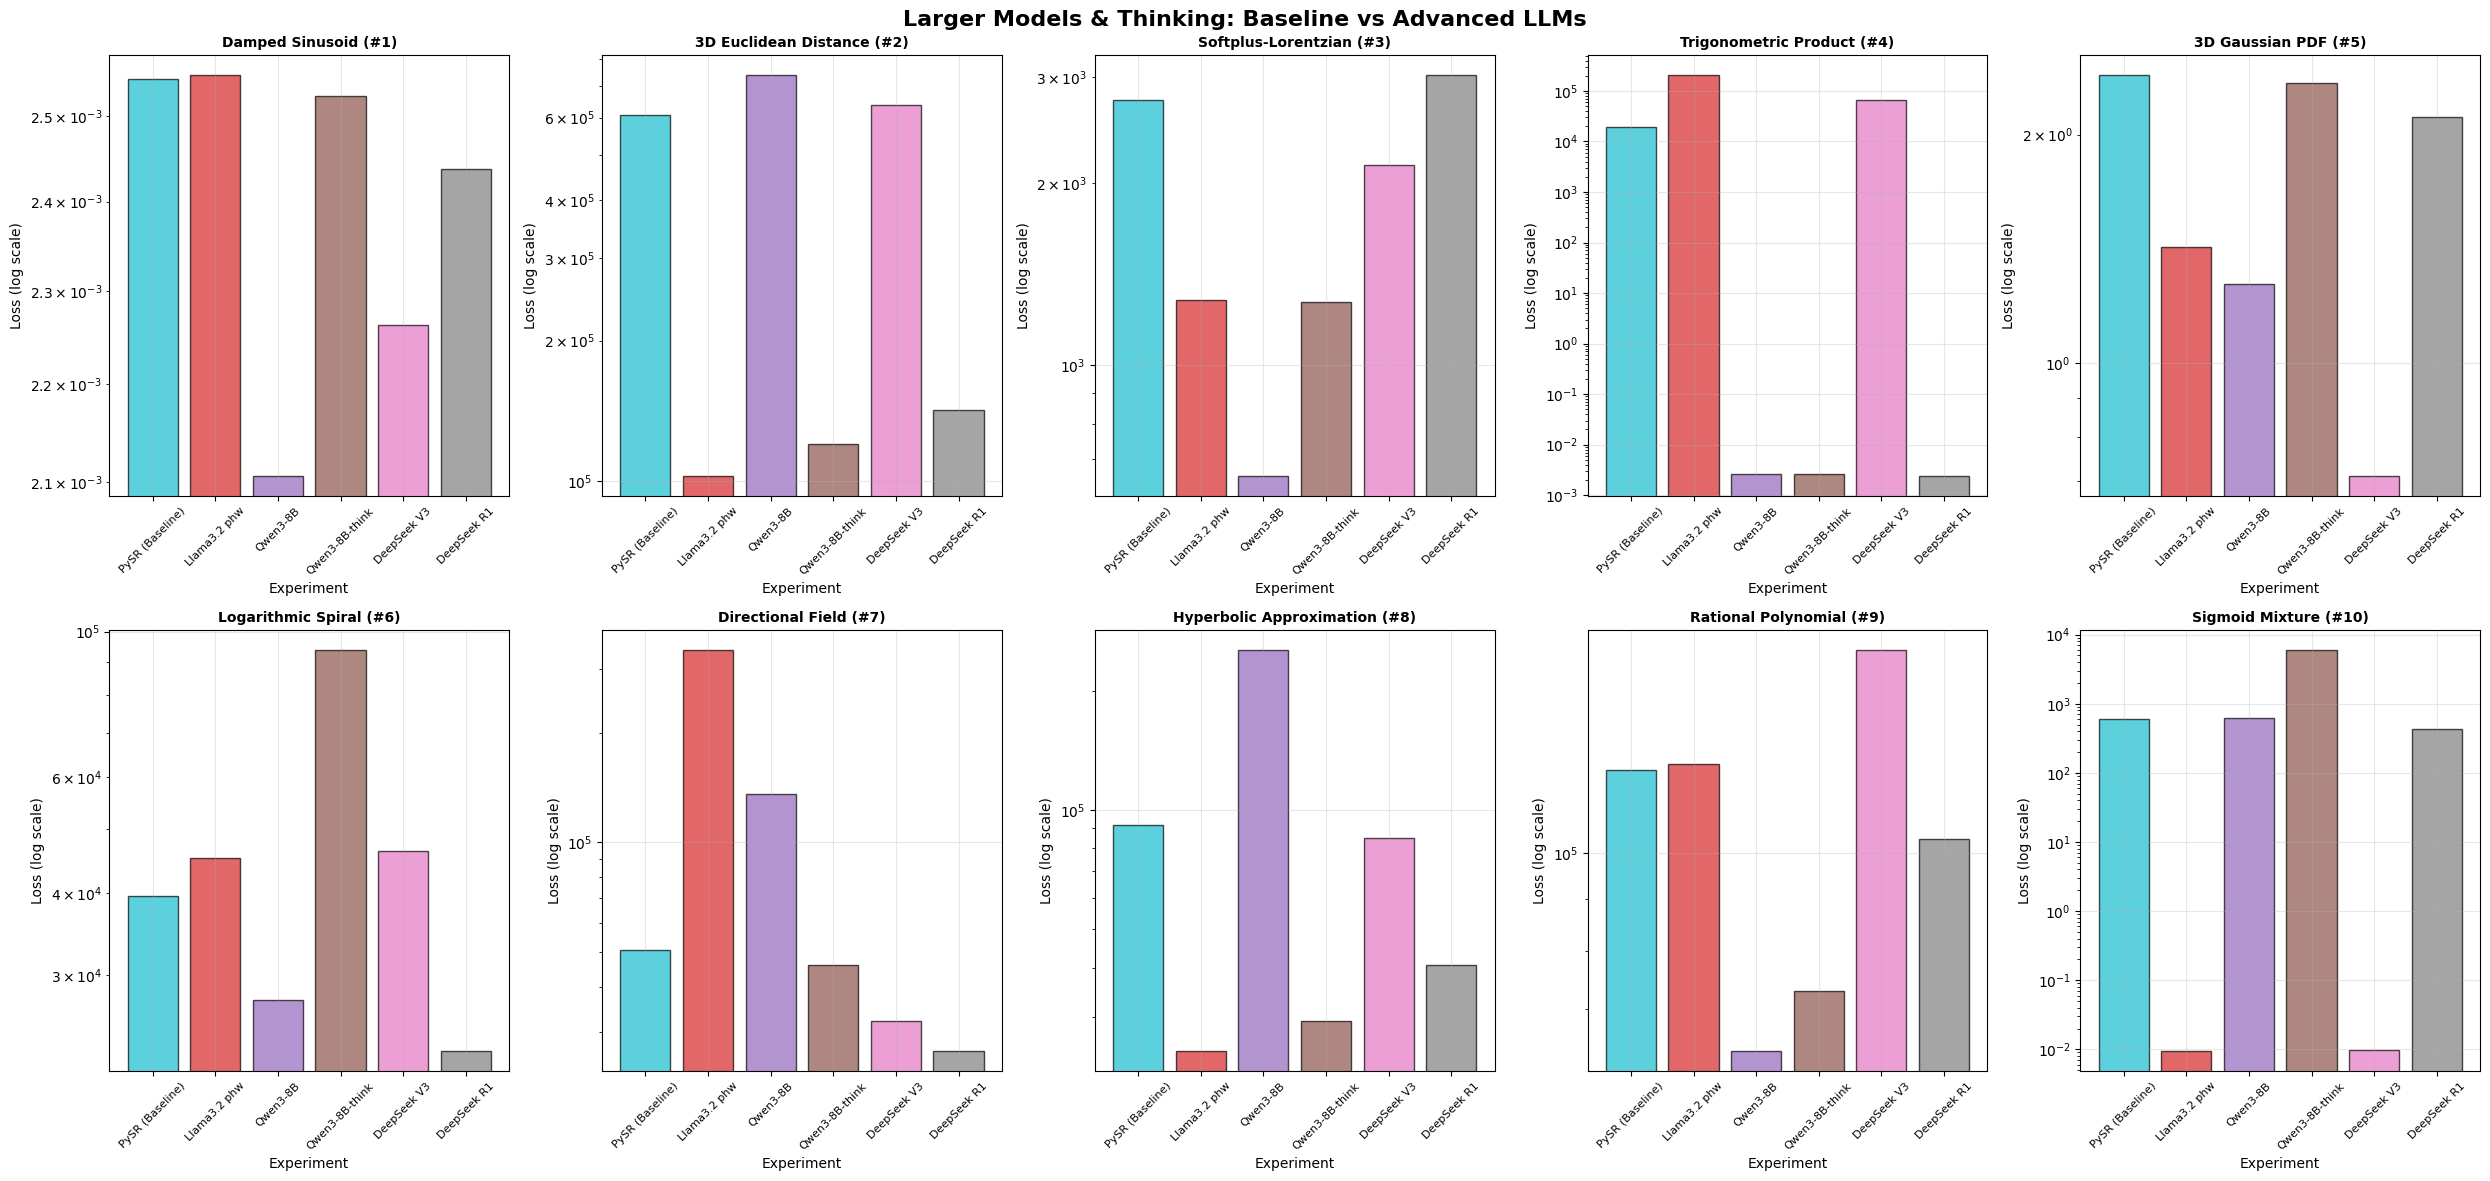


Larger Models Win Count:
  PySR (Baseline): 0 wins (0.0%)
  Llama3.2 phw: 3 wins (30.0%)
  Qwen3-8B: 3 wins (30.0%)
  Qwen3-8B-think: 0 wins (0.0%)
  DeepSeek V3: 1 wins (10.0%)
  DeepSeek R1: 3 wins (30.0%)

COMPARISON: BASIC vs LARGER MODELS

Basic Settings (Llama3.2 variants) vs Baseline:
  Basic LASR wins: 10/10 (100.0%)
  Baseline wins: 0/10 (0.0%)

Larger Models vs Baseline:
  Larger LASR wins: 10/10 (100.0%)
  Baseline wins: 0/10 (0.0%)

Key Insights:
  - Basic settings improvement over baseline: 100.0 percentage points
  - Larger models improvement over baseline: 100.0 percentage points
  - Basic settings outperform larger models by 0.0 percentage points


In [43]:
# 2. Larger Models & Thinking Ability Exploration
larger_exp_keys = ['baseline', 3, 4, 5, 6, 7]

print("="*80)
print("LARGER MODELS & THINKING ABILITY EXPLORATION")
print("="*80)

# Create plots for larger models
n_equations = len(all_equations)
fig, axes = plt.subplots(2, 5, figsize=(25, 12))
axes = axes.flatten()

for i, eq_num in enumerate(all_equations):
    ax = axes[i]
    
    # Collect loss values for this equation across larger model experiments
    losses_for_eq = []
    exp_names = []
    colors = []
    
    for exp_key in larger_exp_keys:
        if eq_num in exp_data[exp_key]:
            losses_for_eq.append(exp_data[exp_key][eq_num])
            exp_names.append(exp_labels[exp_key])
            if exp_key == 'baseline':
                colors.append('C9')  # Special color for baseline
            else:
                colors.append(f'C{exp_key}')
    
    if losses_for_eq:
        bars = ax.bar(exp_names, losses_for_eq, color=colors, alpha=0.7, edgecolor='black')
        
        # Highlight best and worst performers
        if len(losses_for_eq) > 1:
            min_loss_idx = np.argmin(losses_for_eq)
            max_loss_idx = np.argmax(losses_for_eq)
            # bars[min_loss_idx].set_color('green')
            # bars[min_loss_idx].set_alpha(1.0)
            # bars[max_loss_idx].set_color('red')
            # bars[max_loss_idx].set_alpha(1.0)
        
        ax.set_yscale('log')
        ax.set_xlabel('Experiment', fontsize=10)
        ax.set_ylabel('Loss (log scale)', fontsize=10)
        eq_name = equation_info[eq_num]['name'] if eq_num in equation_info else f'Eq #{eq_num}'
        ax.set_title(f'{eq_name} (#{eq_num})', fontsize=10, fontweight='bold')
        
        # Add loss values as text on bars
        for bar, loss in zip(bars, losses_for_eq):
            height = bar.get_height()
            # ax.text(bar.get_x() + bar.get_width()/2., height * 1.2,
            #        f'{loss:.1e}', ha='center', va='bottom', fontsize=7, rotation=45)
        
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='x', rotation=45, labelsize=8)
    else:
        ax.text(0.5, 0.5, 'No data', transform=ax.transAxes, 
               ha='center', va='center', fontsize=12, style='italic')
        ax.set_title(f'Equation #{eq_num} - No Data', fontsize=12)

# Hide unused subplots
for i in range(n_equations, len(axes)):
    axes[i].set_visible(False)

plt.suptitle('Larger Models & Thinking: Baseline vs Advanced LLMs', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Larger models summary
print(f"\nLarger Models Win Count:")
larger_win_counts = {'baseline': 0}
for exp_key in [3, 4, 5, 6, 7]:
    larger_win_counts[exp_key] = 0
larger_total = 0

for eq_num in all_equations:
    valid_experiments = []
    valid_losses = []
    
    for exp_key in larger_exp_keys:
        if eq_num in exp_data[exp_key]:
            valid_experiments.append(exp_key)
            valid_losses.append(exp_data[exp_key][eq_num])
    
    if valid_losses:
        best_exp_idx = np.argmin(valid_losses)
        best_exp = valid_experiments[best_exp_idx]
        larger_win_counts[best_exp] += 1
        larger_total += 1

for exp_key in larger_exp_keys:
    wins = larger_win_counts[exp_key]
    win_percentage = (wins / larger_total) * 100 if larger_total > 0 else 0
    print(f"  {exp_labels[exp_key]}: {wins} wins ({win_percentage:.1f}%)")

# Compare basic vs larger model performance
print(f"\n" + "="*80)
print("COMPARISON: BASIC vs LARGER MODELS")
print("="*80)

print(f"\nBasic Settings (Llama3.2 variants) vs Baseline:")
basic_lasr_wins = sum(basic_win_counts[i] for i in range(4))
basic_baseline_wins = basic_win_counts['baseline']
print(f"  Basic LASR wins: {basic_lasr_wins}/{basic_total} ({(basic_lasr_wins/basic_total)*100:.1f}%)")
print(f"  Baseline wins: {basic_baseline_wins}/{basic_total} ({(basic_baseline_wins/basic_total)*100:.1f}%)")

print(f"\nLarger Models vs Baseline:")
larger_lasr_wins = sum(larger_win_counts[i] for i in [3, 4, 5, 6, 7])
larger_baseline_wins = larger_win_counts['baseline']
print(f"  Larger LASR wins: {larger_lasr_wins}/{larger_total} ({(larger_lasr_wins/larger_total)*100:.1f}%)")
print(f"  Baseline wins: {larger_baseline_wins}/{larger_total} ({(larger_baseline_wins/larger_total)*100:.1f}%)")

print(f"\nKey Insights:")
print(f"  - Basic settings improvement over baseline: {((basic_lasr_wins/basic_total) - (basic_baseline_wins/basic_total))*100:.1f} percentage points")
print(f"  - Larger models improvement over baseline: {((larger_lasr_wins/larger_total) - (larger_baseline_wins/larger_total))*100:.1f} percentage points")
if larger_lasr_wins/larger_total > basic_lasr_wins/basic_total:
    improvement = ((larger_lasr_wins/larger_total) - (basic_lasr_wins/basic_total))*100
    print(f"  - Larger models outperform basic settings by {improvement:.1f} percentage points")
else:
    decline = ((basic_lasr_wins/basic_total) - (larger_lasr_wins/larger_total))*100
    print(f"  - Basic settings outperform larger models by {decline:.1f} percentage points")


NORMALIZED AGGREGATED LOSS COMPARISON


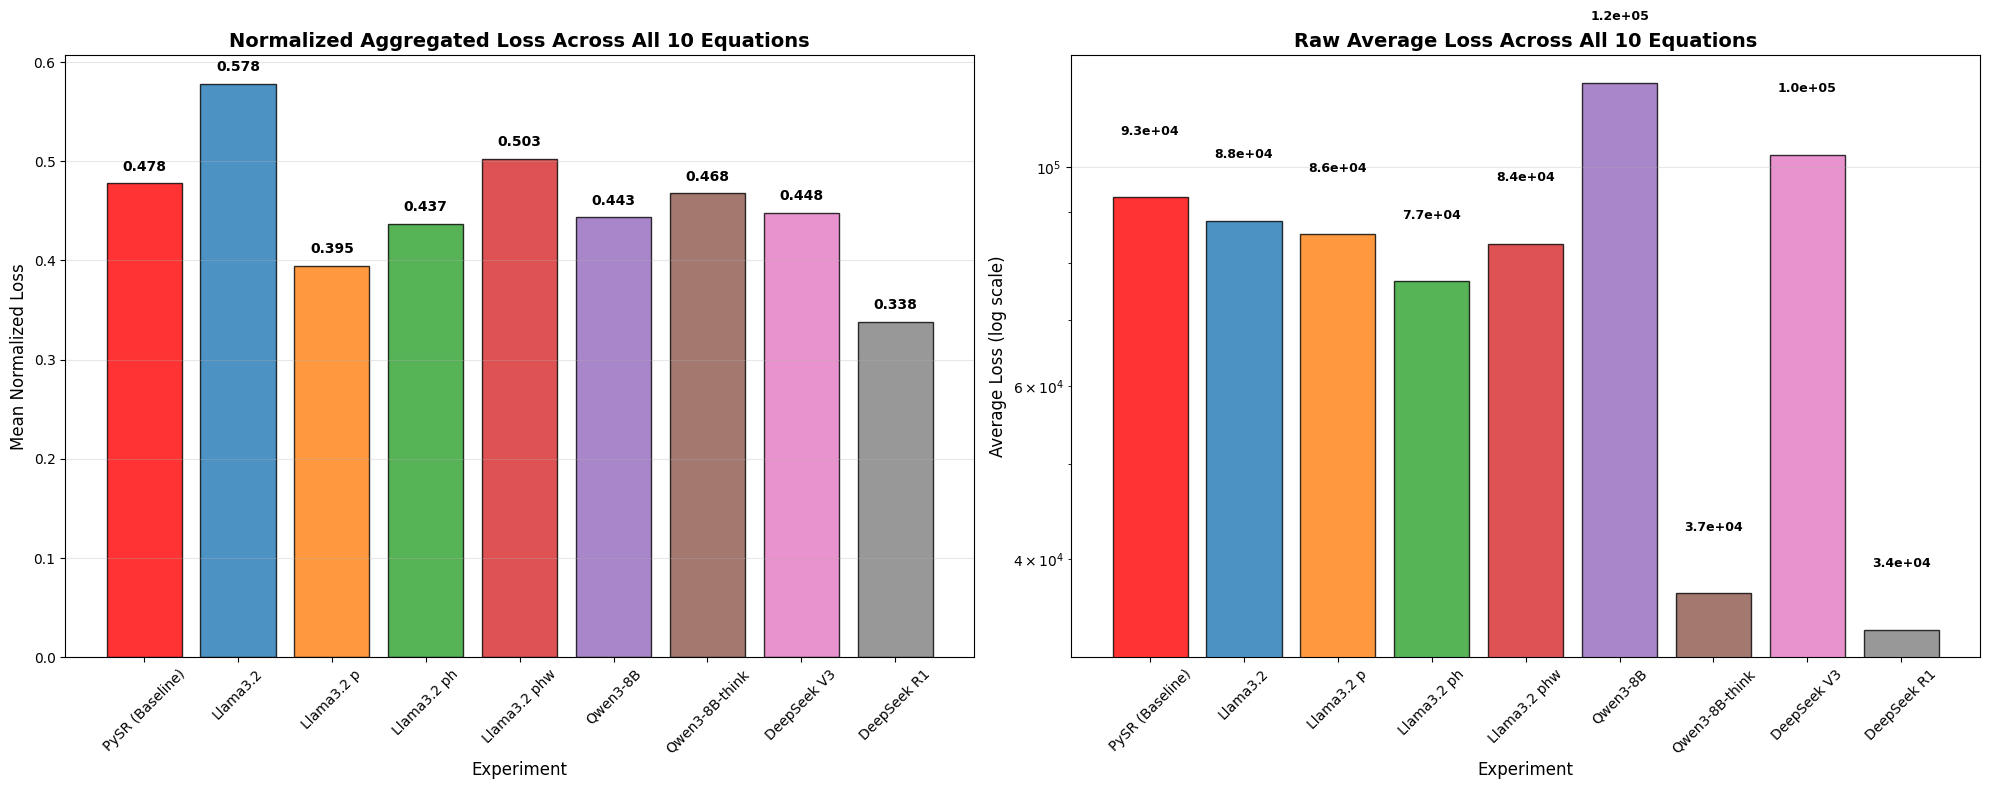


Normalized Aggregated Loss Rankings:
  1. DeepSeek R1: 0.3382
  2. Llama3.2 p: 0.3948
  3. Llama3.2 ph: 0.4367
  4. Qwen3-8B: 0.4434
  5. DeepSeek V3: 0.4480
  6. Qwen3-8B-think: 0.4678
  7. PySR (Baseline): 0.4777
  8. Llama3.2 phw: 0.5028
  9. Llama3.2: 0.5782

Raw Average Loss Rankings:
  1. DeepSeek R1: 3.39e+04
  2. Qwen3-8B-think: 3.69e+04
  3. Llama3.2 ph: 7.66e+04
  4. Llama3.2 phw: 8.36e+04
  5. Llama3.2 p: 8.55e+04
  6. Llama3.2: 8.83e+04
  7. PySR (Baseline): 9.33e+04
  8. DeepSeek V3: 1.03e+05
  9. Qwen3-8B: 1.22e+05

Improvement Analysis:
  Best normalized loss: 0.3382
  Baseline normalized loss: 0.4777
  Normalized improvement ratio: 1.41x
  Best raw average loss: 3.39e+04
  Baseline raw average loss: 9.33e+04
  Raw improvement ratio: 2.75x
  Best performing experiment: DeepSeek R1

Equation-wise Normalized Loss Contribution to Overall Score:
  Damped Sinusoid (#1):
    PySR (Baseline): 0.9013
    Llama3.2: 0.8181
    Llama3.2 p: 1.0000
    Llama3.2 ph: 0.8714
    Llama3

In [44]:
# Normalized Aggregated Loss Comparison
print("="*80)
print("NORMALIZED AGGREGATED LOSS COMPARISON")
print("="*80)

# Calculate normalized aggregated loss for each experiment
normalized_losses = {}
experiment_keys = ['baseline'] + list(range(8))

for exp_key in experiment_keys:
    exp_losses = []
    for eq_num in all_equations:
        if eq_num in exp_data[exp_key]:
            exp_losses.append(exp_data[exp_key][eq_num])
    
    if exp_losses:
        # Normalize each equation's loss by its maximum value across all experiments
        normalized_eq_losses = []
        for i, eq_num in enumerate(all_equations):
            if eq_num in exp_data[exp_key]:
                # Find max loss for this equation across all experiments
                max_loss_for_eq = 0
                for other_exp_key in experiment_keys:
                    if eq_num in exp_data[other_exp_key]:
                        max_loss_for_eq = max(max_loss_for_eq, exp_data[other_exp_key][eq_num])
                
                # Normalize the loss
                normalized_loss = exp_data[exp_key][eq_num] / max_loss_for_eq if max_loss_for_eq > 0 else 0
                normalized_eq_losses.append(normalized_loss)
        
        # Calculate mean of normalized losses
        mean_normalized_loss = np.mean(normalized_eq_losses) if normalized_eq_losses else 0
        normalized_losses[exp_key] = mean_normalized_loss

# Create aggregated comparison plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Plot 1: Normalized aggregated loss
exp_names = []
norm_losses = []
colors = []

for exp_key in experiment_keys:
    if exp_key in normalized_losses:
        exp_names.append(exp_labels[exp_key])
        norm_losses.append(normalized_losses[exp_key])
        if exp_key == 'baseline':
            colors.append('red')
        else:
            colors.append(f'C{exp_key}')

bars1 = ax1.bar(exp_names, norm_losses, color=colors, alpha=0.8, edgecolor='black')
ax1.set_ylabel('Mean Normalized Loss', fontsize=12)
ax1.set_xlabel('Experiment', fontsize=12)
ax1.set_title('Normalized Aggregated Loss Across All 10 Equations', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')
ax1.tick_params(axis='x', rotation=45)

# Add values on bars
for bar, loss in zip(bars1, norm_losses):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{loss:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 2: Raw average loss (log scale)
raw_avg_losses = []
for exp_key in experiment_keys:
    exp_losses = []
    for eq_num in all_equations:
        if eq_num in exp_data[exp_key]:
            exp_losses.append(exp_data[exp_key][eq_num])
    avg_loss = np.mean(exp_losses) if exp_losses else 0
    raw_avg_losses.append(avg_loss)

bars2 = ax2.bar(exp_names, raw_avg_losses, color=colors, alpha=0.8, edgecolor='black')
ax2.set_yscale('log')
ax2.set_ylabel('Average Loss (log scale)', fontsize=12)
ax2.set_xlabel('Experiment', fontsize=12)
ax2.set_title('Raw Average Loss Across All 10 Equations', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
ax2.tick_params(axis='x', rotation=45)

# Add values on bars for raw losses
for bar, loss in zip(bars2, raw_avg_losses):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height * 1.15,
            f'{loss:.1e}', ha='center', va='bottom', fontsize=9, fontweight='bold', rotation=0)

plt.tight_layout()
plt.show()

# Print detailed statistics
print(f"\nNormalized Aggregated Loss Rankings:")
sorted_normalized = sorted([(exp_labels[k], v) for k, v in normalized_losses.items()], key=lambda x: x[1])
for i, (exp_name, norm_loss) in enumerate(sorted_normalized):
    print(f"  {i+1}. {exp_name}: {norm_loss:.4f}")

print(f"\nRaw Average Loss Rankings:")
raw_loss_data = [(exp_labels[experiment_keys[i]], raw_avg_losses[i]) for i in range(len(experiment_keys))]
sorted_raw = sorted(raw_loss_data, key=lambda x: x[1])
for i, (exp_name, raw_loss) in enumerate(sorted_raw):
    print(f"  {i+1}. {exp_name}: {raw_loss:.2e}")

# Calculate improvement ratios
best_norm_loss = min(normalized_losses.values())
baseline_norm_loss = normalized_losses['baseline']
best_raw_loss = min(raw_avg_losses)
baseline_raw_loss = raw_avg_losses[0]  # baseline is first in experiment_keys

print(f"\nImprovement Analysis:")
print(f"  Best normalized loss: {best_norm_loss:.4f}")  
print(f"  Baseline normalized loss: {baseline_norm_loss:.4f}")
print(f"  Normalized improvement ratio: {baseline_norm_loss/best_norm_loss:.2f}x")
print(f"  Best raw average loss: {best_raw_loss:.2e}")
print(f"  Baseline raw average loss: {baseline_raw_loss:.2e}")
print(f"  Raw improvement ratio: {baseline_raw_loss/best_raw_loss:.2f}x")

# Find which experiment achieved best normalized performance
best_exp_key = min(normalized_losses.keys(), key=lambda k: normalized_losses[k])
best_exp_name = exp_labels[best_exp_key]
print(f"  Best performing experiment: {best_exp_name}")

# Equation-wise normalized contribution analysis
print(f"\nEquation-wise Normalized Loss Contribution to Overall Score:")
for eq_num in all_equations:
    eq_name = equation_info[eq_num]['name'] if eq_num in equation_info else f'Eq #{eq_num}'
    
    # Find max loss for this equation across all experiments
    max_loss_for_eq = 0
    for exp_key in experiment_keys:
        if eq_num in exp_data[exp_key]:
            max_loss_for_eq = max(max_loss_for_eq, exp_data[exp_key][eq_num])
    
    print(f"  {eq_name} (#{eq_num}):")
    for exp_key in experiment_keys:
        if eq_num in exp_data[exp_key]:
            normalized_loss = exp_data[exp_key][eq_num] / max_loss_for_eq if max_loss_for_eq > 0 else 0
            print(f"    {exp_labels[exp_key]}: {normalized_loss:.4f}")
    print()

COMPARISON OF DIFFERENT NORMALIZATION METHODS


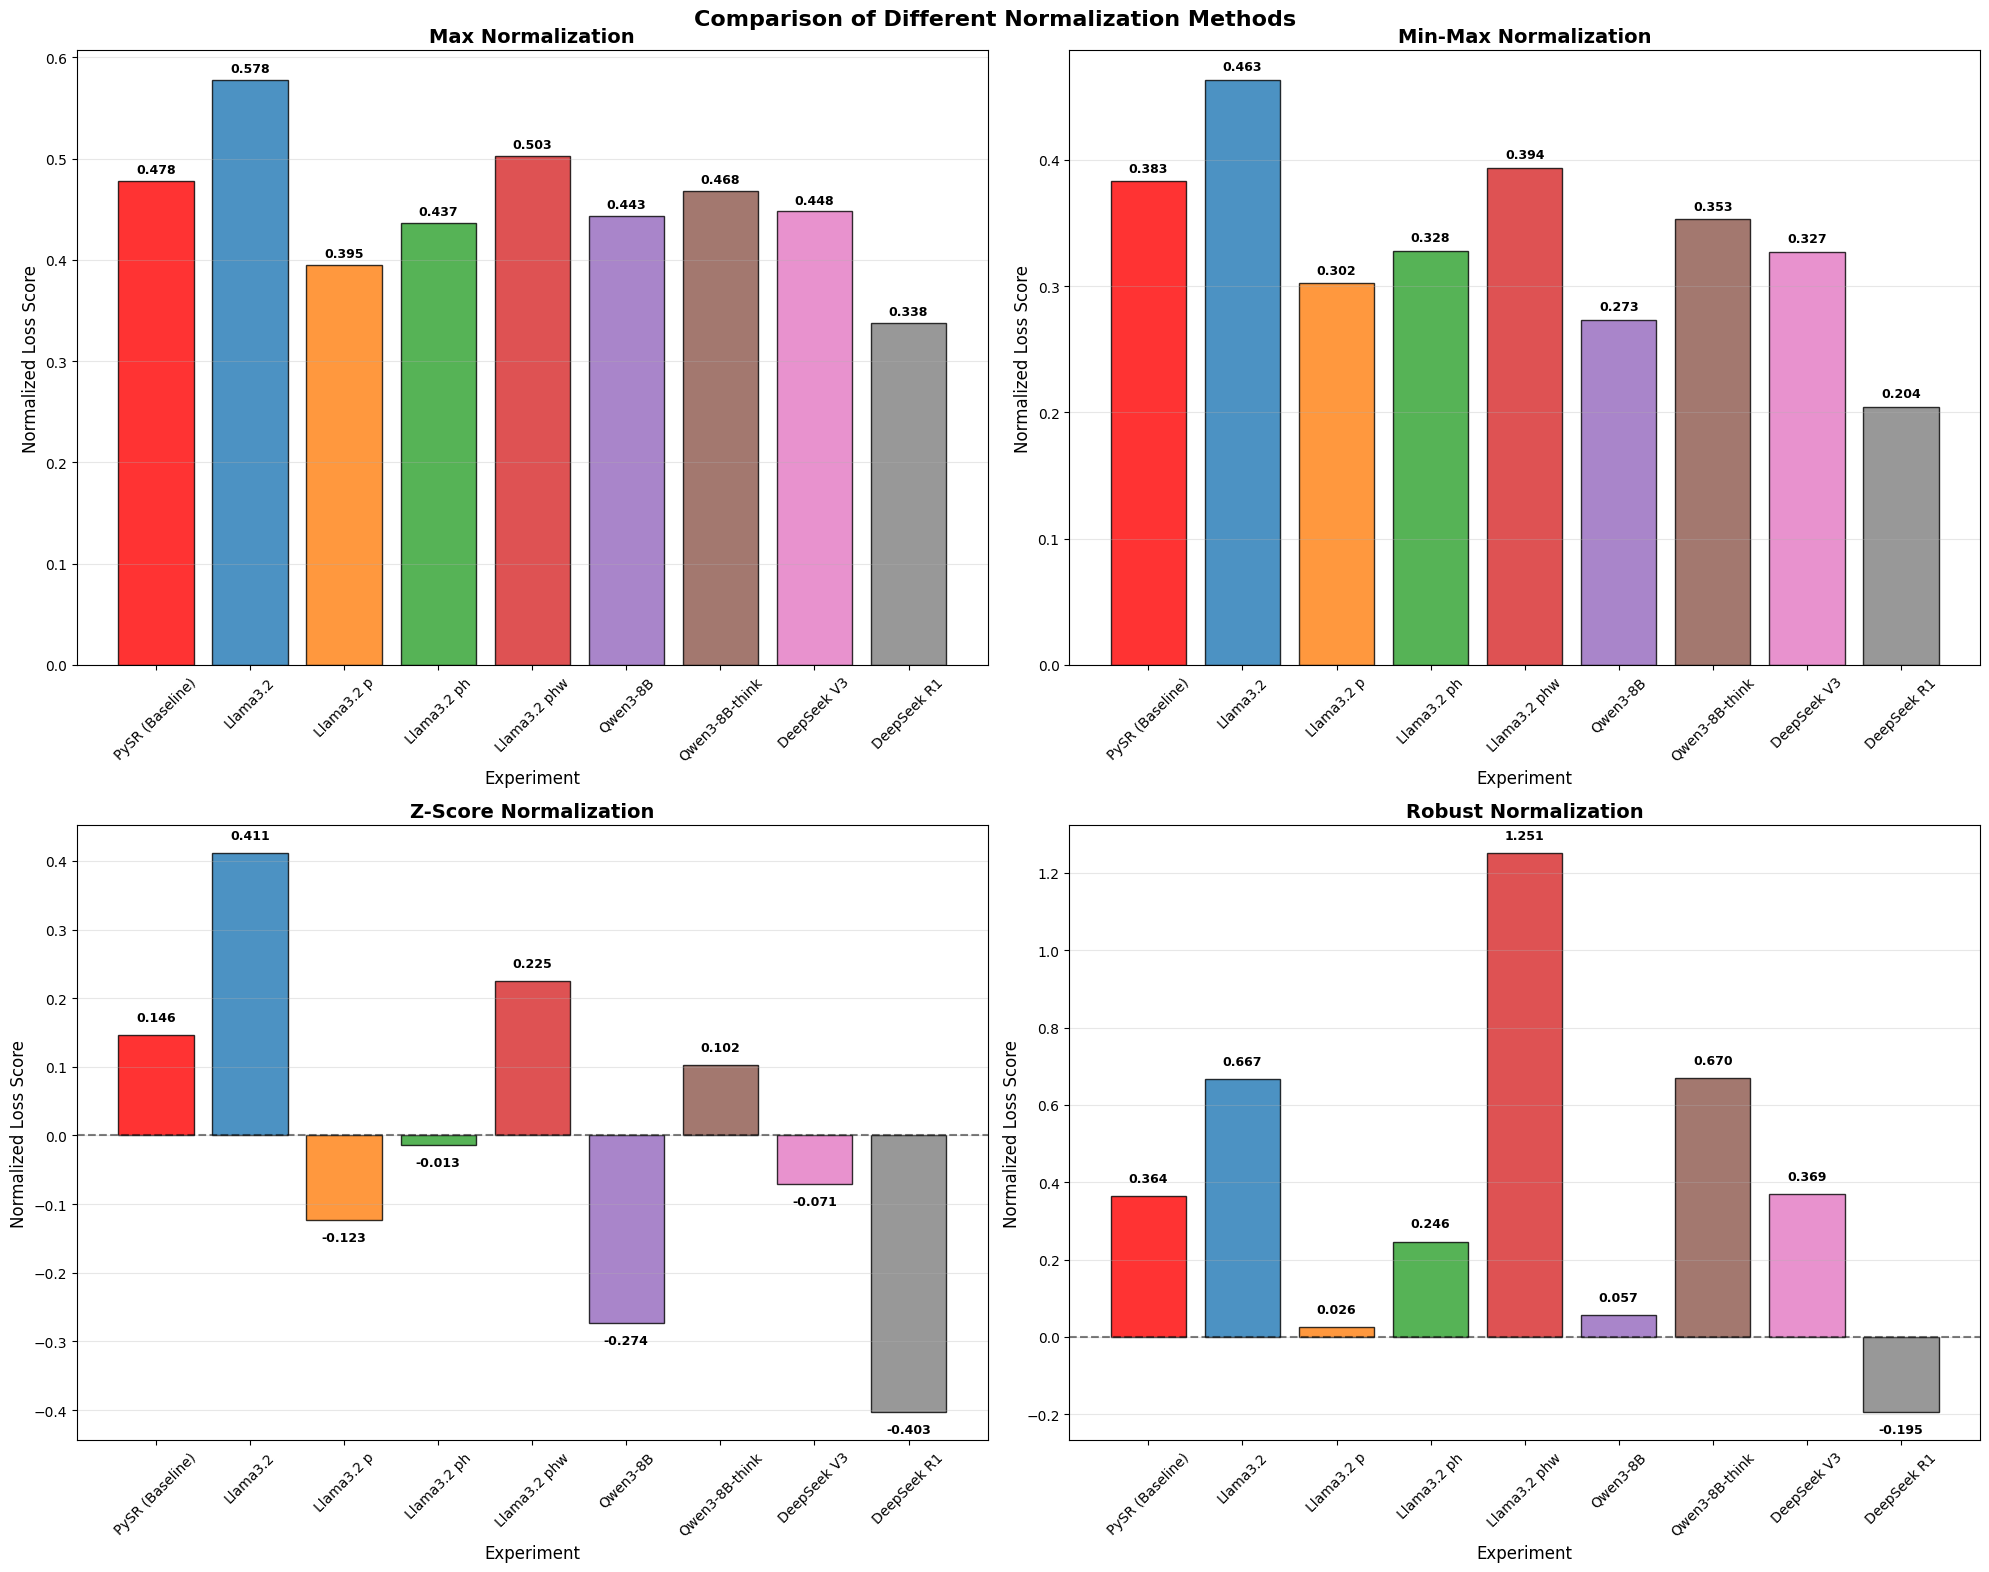


DETAILED RANKINGS BY NORMALIZATION METHOD

MAX NORMALIZATION RANKINGS:
  1. DeepSeek R1: 0.3382
  2. Llama3.2 p: 0.3948
  3. Llama3.2 ph: 0.4367
  4. Qwen3-8B: 0.4434
  5. DeepSeek V3: 0.4480
  6. Qwen3-8B-think: 0.4678
  7. PySR (Baseline): 0.4777
  8. Llama3.2 phw: 0.5028
  9. Llama3.2: 0.5782
  → Best performer: DeepSeek R1

MIN-MAX NORMALIZATION RANKINGS:
  1. DeepSeek R1: 0.2043
  2. Qwen3-8B: 0.2735
  3. Llama3.2 p: 0.3022
  4. DeepSeek V3: 0.3270
  5. Llama3.2 ph: 0.3279
  6. Qwen3-8B-think: 0.3529
  7. PySR (Baseline): 0.3829
  8. Llama3.2 phw: 0.3937
  9. Llama3.2: 0.4635
  → Best performer: DeepSeek R1

Z-SCORE NORMALIZATION RANKINGS:
  1. DeepSeek R1: -0.4029
  2. Qwen3-8B: -0.2736
  3. Llama3.2 p: -0.1232
  4. DeepSeek V3: -0.0711
  5. Llama3.2 ph: -0.0133
  6. Qwen3-8B-think: 0.1020
  7. PySR (Baseline): 0.1460
  8. Llama3.2 phw: 0.2249
  9. Llama3.2: 0.4112
  → Best performer: DeepSeek R1

ROBUST NORMALIZATION RANKINGS:
  1. DeepSeek R1: -0.1946
  2. Llama3.2 p: 0.0256
 

In [45]:
# Multiple Normalization Methods Comparison
print("="*100)
print("COMPARISON OF DIFFERENT NORMALIZATION METHODS")
print("="*100)

import numpy as np
from scipy import stats

# Define normalization functions
def max_normalization(losses_dict, experiment_keys):
    """Max normalization: loss / max_loss"""
    normalized_losses = {}
    
    for exp_key in experiment_keys:
        normalized_eq_losses = []
        for eq_num in all_equations:
            if eq_num in losses_dict[exp_key]:
                # Find max loss for this equation across all experiments
                max_loss_for_eq = 0
                for other_exp_key in experiment_keys:
                    if eq_num in losses_dict[other_exp_key]:
                        max_loss_for_eq = max(max_loss_for_eq, losses_dict[other_exp_key][eq_num])
                
                # Normalize the loss
                normalized_loss = losses_dict[exp_key][eq_num] / max_loss_for_eq if max_loss_for_eq > 0 else 0
                normalized_eq_losses.append(normalized_loss)
        
        # Calculate mean of normalized losses
        mean_normalized_loss = np.mean(normalized_eq_losses) if normalized_eq_losses else 0
        normalized_losses[exp_key] = mean_normalized_loss
    
    return normalized_losses

def minmax_normalization(losses_dict, experiment_keys):
    """Min-Max normalization: (loss - min_loss) / (max_loss - min_loss)"""
    normalized_losses = {}
    
    for exp_key in experiment_keys:
        normalized_eq_losses = []
        for eq_num in all_equations:
            if eq_num in losses_dict[exp_key]:
                # Find min and max loss for this equation across all experiments
                losses_for_eq = []
                for other_exp_key in experiment_keys:
                    if eq_num in losses_dict[other_exp_key]:
                        losses_for_eq.append(losses_dict[other_exp_key][eq_num])
                
                if losses_for_eq:
                    min_loss = min(losses_for_eq)
                    max_loss = max(losses_for_eq)
                    
                    # Normalize the loss
                    if max_loss > min_loss:
                        normalized_loss = (losses_dict[exp_key][eq_num] - min_loss) / (max_loss - min_loss)
                    else:
                        normalized_loss = 0  # All losses are the same
                    normalized_eq_losses.append(normalized_loss)
        
        # Calculate mean of normalized losses
        mean_normalized_loss = np.mean(normalized_eq_losses) if normalized_eq_losses else 0
        normalized_losses[exp_key] = mean_normalized_loss
    
    return normalized_losses

def zscore_normalization(losses_dict, experiment_keys):
    """Z-score normalization: (loss - mean) / std"""
    normalized_losses = {}
    
    for exp_key in experiment_keys:
        normalized_eq_losses = []
        for eq_num in all_equations:
            if eq_num in losses_dict[exp_key]:
                # Find all losses for this equation across all experiments
                losses_for_eq = []
                for other_exp_key in experiment_keys:
                    if eq_num in losses_dict[other_exp_key]:
                        losses_for_eq.append(losses_dict[other_exp_key][eq_num])
                
                if len(losses_for_eq) > 1:
                    mean_loss = np.mean(losses_for_eq)
                    std_loss = np.std(losses_for_eq)
                    
                    # Normalize the loss
                    if std_loss > 0:
                        normalized_loss = (losses_dict[exp_key][eq_num] - mean_loss) / std_loss
                    else:
                        normalized_loss = 0  # All losses are the same
                    normalized_eq_losses.append(normalized_loss)
        
        # Calculate mean of normalized losses (note: this can be negative)
        mean_normalized_loss = np.mean(normalized_eq_losses) if normalized_eq_losses else 0
        normalized_losses[exp_key] = mean_normalized_loss
    
    return normalized_losses

def robust_normalization(losses_dict, experiment_keys):
    """Robust normalization: (loss - median) / IQR"""
    normalized_losses = {}
    
    for exp_key in experiment_keys:
        normalized_eq_losses = []
        for eq_num in all_equations:
            if eq_num in losses_dict[exp_key]:
                # Find all losses for this equation across all experiments
                losses_for_eq = []
                for other_exp_key in experiment_keys:
                    if eq_num in losses_dict[other_exp_key]:
                        losses_for_eq.append(losses_dict[other_exp_key][eq_num])
                
                if len(losses_for_eq) > 1:
                    median_loss = np.median(losses_for_eq)
                    q75 = np.percentile(losses_for_eq, 75)
                    q25 = np.percentile(losses_for_eq, 25)
                    iqr = q75 - q25
                    
                    # Normalize the loss
                    if iqr > 0:
                        normalized_loss = (losses_dict[exp_key][eq_num] - median_loss) / iqr
                    else:
                        normalized_loss = 0  # All losses are the same
                    normalized_eq_losses.append(normalized_loss)
        
        # Calculate mean of normalized losses (note: this can be negative)
        mean_normalized_loss = np.mean(normalized_eq_losses) if normalized_eq_losses else 0
        normalized_losses[exp_key] = mean_normalized_loss
    
    return normalized_losses

# Apply all normalization methods
experiment_keys = ['baseline'] + list(range(8))

norm_methods = {
    'Max Normalization': max_normalization(exp_data, experiment_keys),
    'Min-Max Normalization': minmax_normalization(exp_data, experiment_keys),
    'Z-Score Normalization': zscore_normalization(exp_data, experiment_keys),
    'Robust Normalization': robust_normalization(exp_data, experiment_keys)
}

# Create comprehensive comparison plot
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
axes = axes.flatten()

colors_map = {}
for exp_key in experiment_keys:
    if exp_key == 'baseline':
        colors_map[exp_key] = 'red'
    else:
        colors_map[exp_key] = f'C{exp_key}'

for i, (method_name, normalized_data) in enumerate(norm_methods.items()):
    ax = axes[i]
    
    exp_names = []
    norm_losses = []
    colors = []
    
    for exp_key in experiment_keys:
        if exp_key in normalized_data:
            exp_names.append(exp_labels[exp_key])
            norm_losses.append(normalized_data[exp_key])
            colors.append(colors_map[exp_key])
    
    bars = ax.bar(exp_names, norm_losses, color=colors, alpha=0.8, edgecolor='black')
    ax.set_ylabel('Normalized Loss Score', fontsize=12)
    ax.set_xlabel('Experiment', fontsize=12)
    ax.set_title(f'{method_name}', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    ax.tick_params(axis='x', rotation=45)
    
    # Add values on bars
    for bar, loss in zip(bars, norm_losses):
        height = bar.get_height()
        if height >= 0:
            va = 'bottom'
            y_pos = height + (max(norm_losses) - min(norm_losses)) * 0.02
        else:
            va = 'top'
            y_pos = height - (max(norm_losses) - min(norm_losses)) * 0.02
        ax.text(bar.get_x() + bar.get_width()/2., y_pos,
                f'{loss:.3f}', ha='center', va=va, fontsize=9, fontweight='bold')
    
    # Add horizontal line at 0 for methods that can have negative values
    if method_name in ['Z-Score Normalization', 'Robust Normalization']:
        ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)

plt.suptitle('Comparison of Different Normalization Methods', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Print detailed rankings for each method
print("\n" + "="*100)
print("DETAILED RANKINGS BY NORMALIZATION METHOD")
print("="*100)

for method_name, normalized_data in norm_methods.items():
    print(f"\n{method_name.upper()} RANKINGS:")
    sorted_data = sorted([(exp_labels[k], v) for k, v in normalized_data.items()], 
                        key=lambda x: x[1])
    
    for i, (exp_name, norm_loss) in enumerate(sorted_data):
        print(f"  {i+1}. {exp_name}: {norm_loss:.4f}")
    
    # Find best performer
    best_exp_key = min(normalized_data.keys(), key=lambda k: normalized_data[k])
    best_exp_name = exp_labels[best_exp_key]
    print(f"  → Best performer: {best_exp_name}")

# Consistency analysis across methods
print(f"\n" + "="*100)
print("CONSISTENCY ANALYSIS ACROSS NORMALIZATION METHODS")
print("="*100)

# Count how many times each experiment appears in top 3
top3_counts = {exp_key: 0 for exp_key in experiment_keys}
winner_counts = {exp_key: 0 for exp_key in experiment_keys}

for method_name, normalized_data in norm_methods.items():
    # Sort by performance (best first)
    sorted_experiments = sorted(normalized_data.keys(), key=lambda k: normalized_data[k])
    
    # Count winner
    winner_counts[sorted_experiments[0]] += 1
    
    # Count top 3
    for exp_key in sorted_experiments[:3]:
        top3_counts[exp_key] += 1

print("Winner counts across all normalization methods:")
for exp_key, count in sorted(winner_counts.items(), key=lambda x: x[1], reverse=True):
    percentage = (count / len(norm_methods)) * 100
    print(f"  {exp_labels[exp_key]}: {count}/{len(norm_methods)} wins ({percentage:.1f}%)")

print(f"\nTop-3 appearances across all normalization methods:")
for exp_key, count in sorted(top3_counts.items(), key=lambda x: x[1], reverse=True):
    percentage = (count / (len(norm_methods) * 3)) * 100
    print(f"  {exp_labels[exp_key]}: {count}/{len(norm_methods)*3} top-3 appearances ({percentage:.1f}%)")

# Method agreement analysis
print(f"\nMethod Agreement Analysis:")
methods_list = list(norm_methods.keys())
for i in range(len(methods_list)):
    for j in range(i+1, len(methods_list)):
        method1, method2 = methods_list[i], methods_list[j]
        
        # Get rankings for both methods
        ranking1 = sorted(norm_methods[method1].keys(), key=lambda k: norm_methods[method1][k])
        ranking2 = sorted(norm_methods[method2].keys(), key=lambda k: norm_methods[method2][k])
        
        # Calculate Spearman rank correlation
        ranks1 = [ranking1.index(exp_key) + 1 for exp_key in experiment_keys if exp_key in ranking1]
        ranks2 = [ranking2.index(exp_key) + 1 for exp_key in experiment_keys if exp_key in ranking2]
        
        if len(ranks1) == len(ranks2) and len(ranks1) > 1:
            correlation, p_value = stats.spearmanr(ranks1, ranks2)
            print(f"  {method1} vs {method2}: ρ = {correlation:.3f} (p = {p_value:.3f})")

print("\n" + "="*100)

ADVANCED NORMALIZATION METHODS


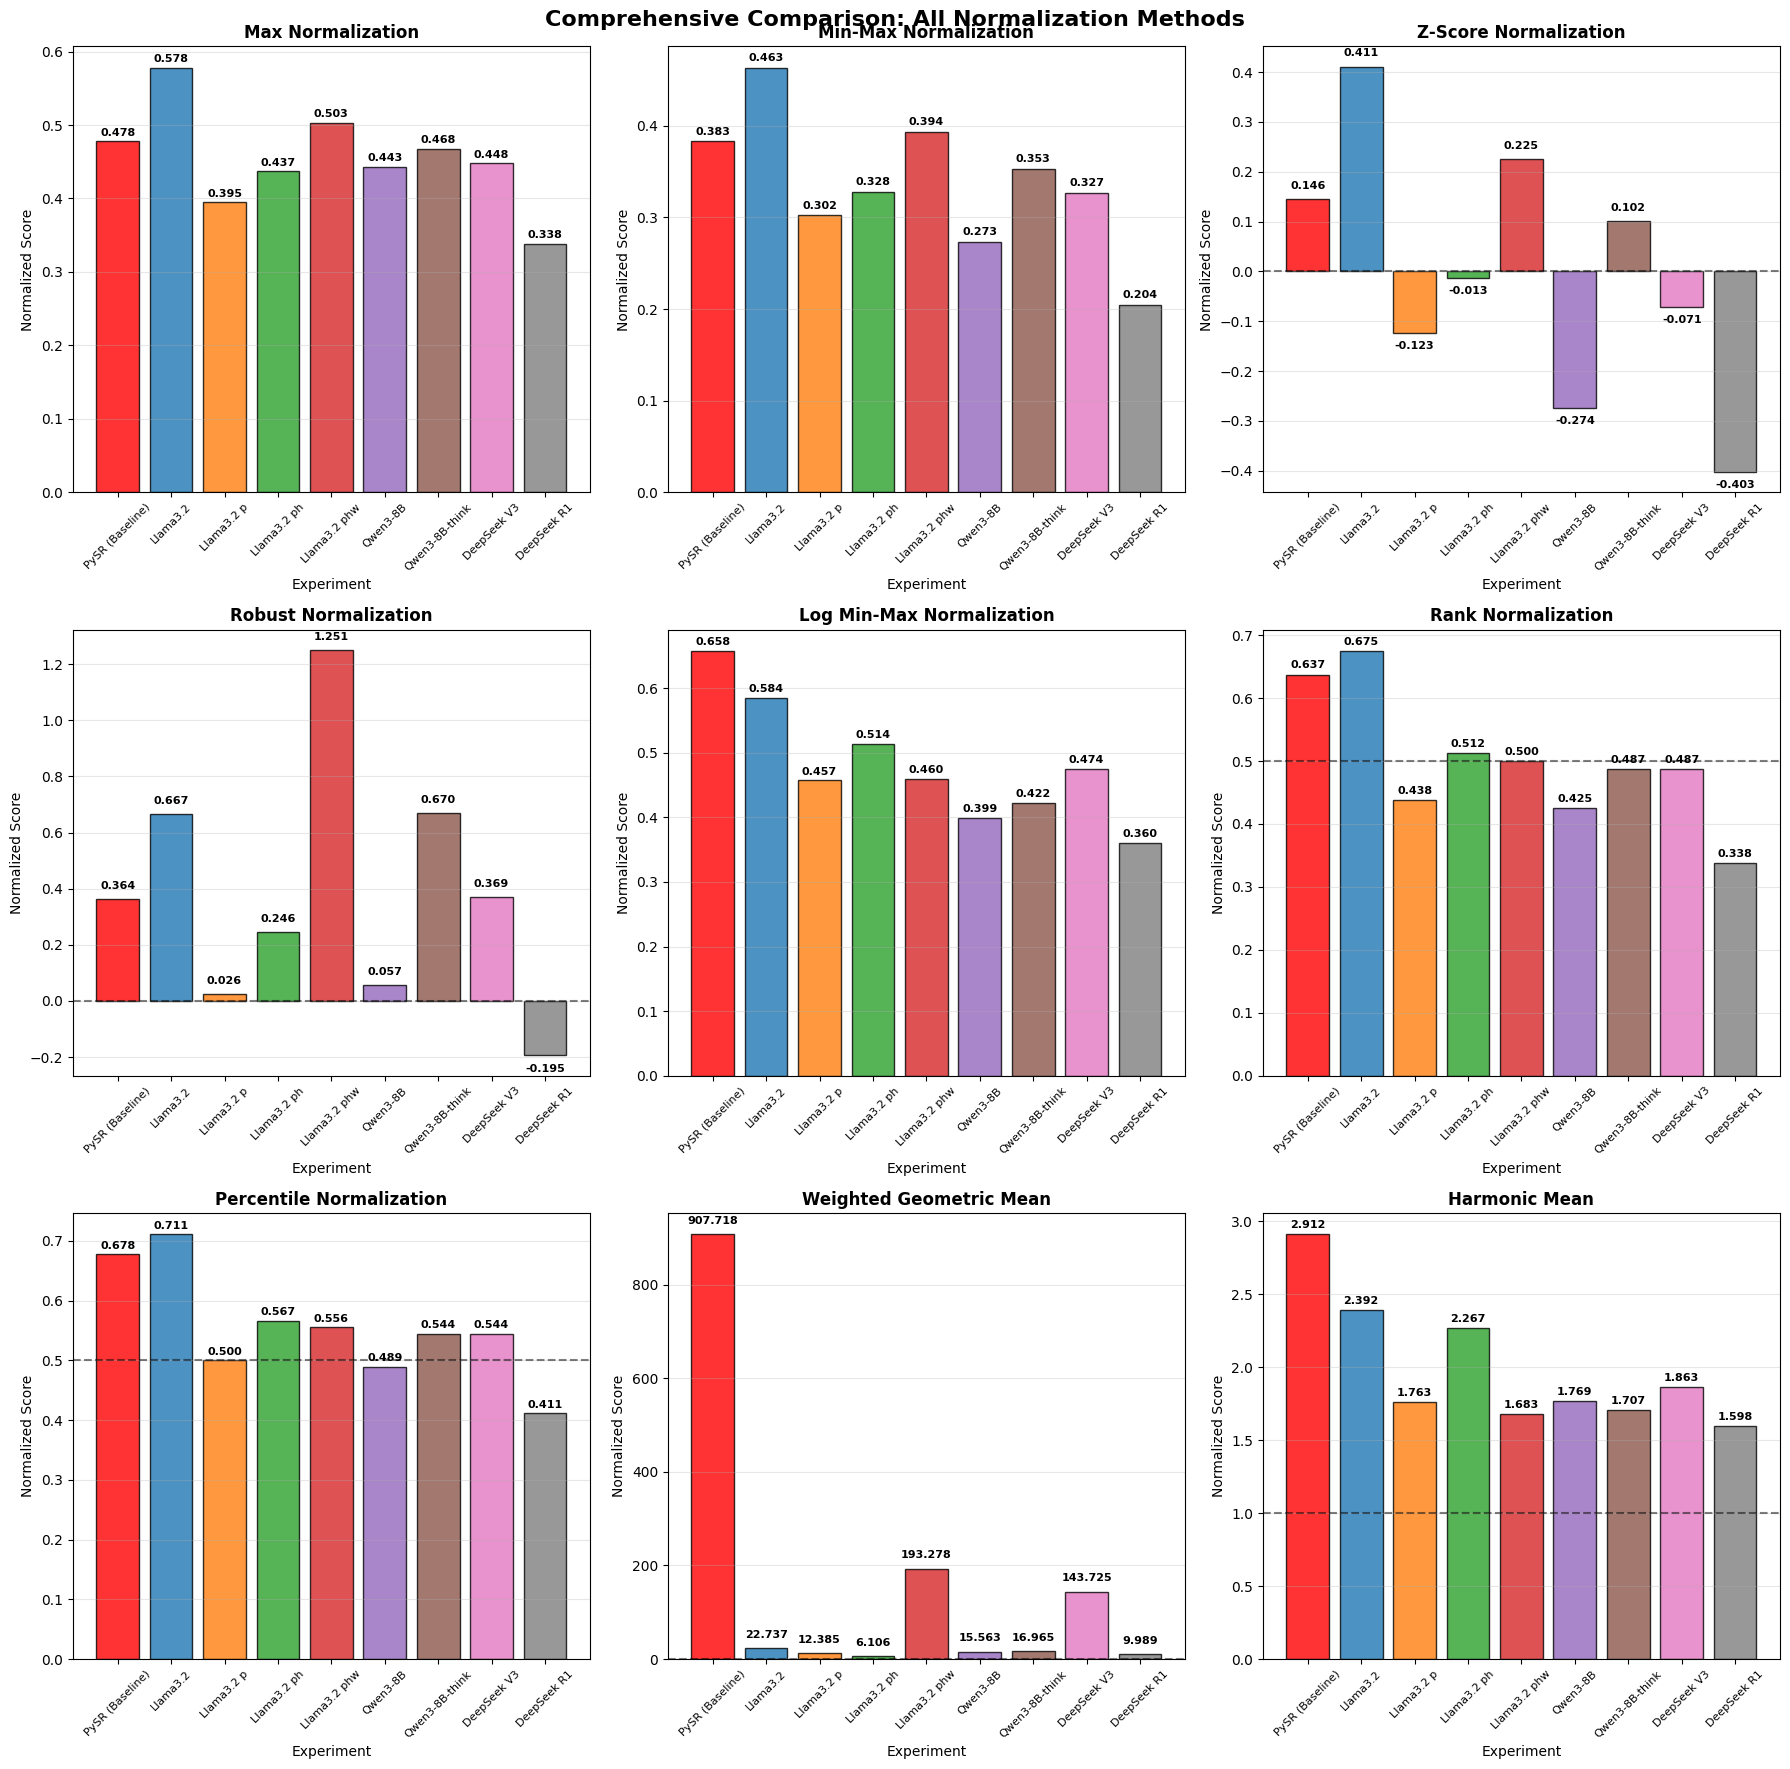


COMPREHENSIVE CONSISTENCY ANALYSIS
Winner frequency across ALL normalization methods:
  DeepSeek R1: 8/9 wins (88.9%)
  Llama3.2 ph: 1/9 wins (11.1%)
  PySR (Baseline): 0/9 wins (0.0%)
  Llama3.2: 0/9 wins (0.0%)
  Llama3.2 p: 0/9 wins (0.0%)
  Llama3.2 phw: 0/9 wins (0.0%)
  Qwen3-8B: 0/9 wins (0.0%)
  Qwen3-8B-think: 0/9 wins (0.0%)
  DeepSeek V3: 0/9 wins (0.0%)

Top-3 frequency across ALL normalization methods:
  DeepSeek R1: 9/27 appearances (33.3%)
  Llama3.2 p: 7/27 appearances (25.9%)
  Qwen3-8B: 6/27 appearances (22.2%)
  Llama3.2 ph: 2/27 appearances (7.4%)
  Qwen3-8B-think: 2/27 appearances (7.4%)
  Llama3.2 phw: 1/27 appearances (3.7%)
  PySR (Baseline): 0/27 appearances (0.0%)
  Llama3.2: 0/27 appearances (0.0%)
  DeepSeek V3: 0/27 appearances (0.0%)

Method-specific winners:
  Max Normalization: DeepSeek R1
  Min-Max Normalization: DeepSeek R1
  Z-Score Normalization: DeepSeek R1
  Robust Normalization: DeepSeek R1
  Log Min-Max Normalization: DeepSeek R1
  Rank Normaliz

In [46]:
# Advanced Normalization Methods
print("="*100)
print("ADVANCED NORMALIZATION METHODS")
print("="*100)

import numpy as np
from scipy import stats
from scipy.stats import rankdata

def log_normalization(losses_dict, experiment_keys):
    """Log-based normalization: log(loss) / max(log(loss))"""
    normalized_losses = {}
    
    for exp_key in experiment_keys:
        normalized_eq_losses = []
        for eq_num in all_equations:
            if eq_num in losses_dict[exp_key]:
                # Find all log losses for this equation
                log_losses_for_eq = []
                for other_exp_key in experiment_keys:
                    if eq_num in losses_dict[other_exp_key]:
                        # Add small epsilon to avoid log(0)
                        log_loss = np.log(losses_dict[other_exp_key][eq_num] + 1e-10)
                        log_losses_for_eq.append(log_loss)
                
                if log_losses_for_eq:
                    max_log_loss = max(log_losses_for_eq)
                    min_log_loss = min(log_losses_for_eq)
                    
                    current_log_loss = np.log(losses_dict[exp_key][eq_num] + 1e-10)
                    
                    # Normalize using min-max on log scale
                    if max_log_loss > min_log_loss:
                        normalized_loss = (current_log_loss - min_log_loss) / (max_log_loss - min_log_loss)
                    else:
                        normalized_loss = 0
                    normalized_eq_losses.append(normalized_loss)
        
        mean_normalized_loss = np.mean(normalized_eq_losses) if normalized_eq_losses else 0
        normalized_losses[exp_key] = mean_normalized_loss
    
    return normalized_losses

def rank_normalization(losses_dict, experiment_keys):
    """Rank-based normalization: rank / max_rank"""
    normalized_losses = {}
    
    for exp_key in experiment_keys:
        normalized_eq_losses = []
        for eq_num in all_equations:
            if eq_num in losses_dict[exp_key]:
                # Find all losses for this equation
                losses_for_eq = []
                exp_keys_for_eq = []
                for other_exp_key in experiment_keys:
                    if eq_num in losses_dict[other_exp_key]:
                        losses_for_eq.append(losses_dict[other_exp_key][eq_num])
                        exp_keys_for_eq.append(other_exp_key)
                
                if len(losses_for_eq) > 1:
                    # Get ranks (1 = best, n = worst)
                    ranks = rankdata(losses_for_eq, method='min')
                    
                    # Find current experiment's rank
                    current_exp_idx = exp_keys_for_eq.index(exp_key)
                    current_rank = ranks[current_exp_idx]
                    max_rank = len(ranks)
                    
                    # Normalize rank (0 = best, 1 = worst)
                    normalized_loss = (current_rank - 1) / (max_rank - 1)
                    normalized_eq_losses.append(normalized_loss)
        
        mean_normalized_loss = np.mean(normalized_eq_losses) if normalized_eq_losses else 0
        normalized_losses[exp_key] = mean_normalized_loss
    
    return normalized_losses

def percentile_normalization(losses_dict, experiment_keys):
    """Percentile-based normalization"""
    normalized_losses = {}
    
    for exp_key in experiment_keys:
        normalized_eq_losses = []
        for eq_num in all_equations:
            if eq_num in losses_dict[exp_key]:
                # Find all losses for this equation
                losses_for_eq = []
                for other_exp_key in experiment_keys:
                    if eq_num in losses_dict[other_exp_key]:
                        losses_for_eq.append(losses_dict[other_exp_key][eq_num])
                
                if len(losses_for_eq) > 1:
                    current_loss = losses_dict[exp_key][eq_num]
                    # Calculate percentile rank
                    percentile = stats.percentileofscore(losses_for_eq, current_loss) / 100.0
                    normalized_eq_losses.append(percentile)
        
        mean_normalized_loss = np.mean(normalized_eq_losses) if normalized_eq_losses else 0
        normalized_losses[exp_key] = mean_normalized_loss
    
    return normalized_losses

def weighted_geometric_mean_normalization(losses_dict, experiment_keys):
    """Geometric mean with equation difficulty weighting"""
    normalized_losses = {}
    
    # Calculate equation difficulty weights based on coefficient of variation
    equation_weights = {}
    for eq_num in all_equations:
        losses_for_eq = []
        for exp_key in experiment_keys:
            if eq_num in losses_dict[exp_key]:
                losses_for_eq.append(losses_dict[exp_key][eq_num])
        
        if len(losses_for_eq) > 1:
            cv = np.std(losses_for_eq) / np.mean(losses_for_eq)  # Coefficient of variation
            equation_weights[eq_num] = cv  # Higher CV = more discriminative = higher weight
        else:
            equation_weights[eq_num] = 1.0
    
    # Normalize weights
    total_weight = sum(equation_weights.values())
    for eq_num in equation_weights:
        equation_weights[eq_num] /= total_weight
    
    for exp_key in experiment_keys:
        normalized_eq_losses = []
        weights = []
        
        for eq_num in all_equations:
            if eq_num in losses_dict[exp_key]:
                # Find min loss for this equation
                min_loss_for_eq = float('inf')
                for other_exp_key in experiment_keys:
                    if eq_num in losses_dict[other_exp_key]:
                        min_loss_for_eq = min(min_loss_for_eq, losses_dict[other_exp_key][eq_num])
                
                # Calculate relative performance (geometric)
                current_loss = losses_dict[exp_key][eq_num]
                relative_loss = current_loss / min_loss_for_eq if min_loss_for_eq > 0 else 1.0
                
                normalized_eq_losses.append(np.log(relative_loss))  # Log for geometric mean
                weights.append(equation_weights[eq_num])
        
        if normalized_eq_losses and weights:
            # Weighted geometric mean
            weighted_log_mean = np.average(normalized_eq_losses, weights=weights)
            normalized_losses[exp_key] = np.exp(weighted_log_mean)  # Convert back from log
        else:
            normalized_losses[exp_key] = 1.0
    
    return normalized_losses

def harmonic_mean_normalization(losses_dict, experiment_keys):
    """Harmonic mean of relative performances"""
    normalized_losses = {}
    
    for exp_key in experiment_keys:
        relative_performances = []
        
        for eq_num in all_equations:
            if eq_num in losses_dict[exp_key]:
                # Find best (minimum) loss for this equation
                min_loss_for_eq = float('inf')
                for other_exp_key in experiment_keys:
                    if eq_num in losses_dict[other_exp_key]:
                        min_loss_for_eq = min(min_loss_for_eq, losses_dict[other_exp_key][eq_num])
                
                if min_loss_for_eq > 0:
                    current_loss = losses_dict[exp_key][eq_num]
                    # Relative performance: how many times worse than the best
                    relative_perf = current_loss / min_loss_for_eq
                    relative_performances.append(relative_perf)
        
        if relative_performances:
            # Harmonic mean (more sensitive to large values)
            harmonic_mean = len(relative_performances) / sum(1/rp for rp in relative_performances)
            normalized_losses[exp_key] = harmonic_mean
        else:
            normalized_losses[exp_key] = 1.0
    
    return normalized_losses

# Apply all advanced normalization methods
experiment_keys = ['baseline'] + list(range(8))

advanced_methods = {
    'Log Min-Max Normalization': log_normalization(exp_data, experiment_keys),
    'Rank Normalization': rank_normalization(exp_data, experiment_keys),
    'Percentile Normalization': percentile_normalization(exp_data, experiment_keys),
    'Weighted Geometric Mean': weighted_geometric_mean_normalization(exp_data, experiment_keys),
    'Harmonic Mean': harmonic_mean_normalization(exp_data, experiment_keys)
}

# Combine with previous methods for comparison
all_methods = {**norm_methods, **advanced_methods}

# Create comprehensive comparison plot for all methods
n_methods = len(all_methods)
n_cols = 3
n_rows = (n_methods + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6*n_rows))
if n_rows == 1:
    axes = axes.reshape(1, -1)
axes = axes.flatten()

colors_map = {}
for exp_key in experiment_keys:
    if exp_key == 'baseline':
        colors_map[exp_key] = 'red'
    else:
        colors_map[exp_key] = f'C{exp_key}'

for i, (method_name, normalized_data) in enumerate(all_methods.items()):
    ax = axes[i]
    
    exp_names = []
    norm_losses = []
    colors = []
    
    for exp_key in experiment_keys:
        if exp_key in normalized_data:
            exp_names.append(exp_labels[exp_key])
            norm_losses.append(normalized_data[exp_key])
            colors.append(colors_map[exp_key])
    
    bars = ax.bar(exp_names, norm_losses, color=colors, alpha=0.8, edgecolor='black')
    ax.set_ylabel('Normalized Score', fontsize=10)
    ax.set_xlabel('Experiment', fontsize=10)
    ax.set_title(f'{method_name}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    
    # Add values on bars
    for bar, loss in zip(bars, norm_losses):
        height = bar.get_height()
        if height >= 0:
            va = 'bottom'
            y_pos = height + (max(norm_losses) - min(norm_losses)) * 0.02
        else:
            va = 'top'
            y_pos = height - (max(norm_losses) - min(norm_losses)) * 0.02
        ax.text(bar.get_x() + bar.get_width()/2., y_pos,
                f'{loss:.3f}', ha='center', va=va, fontsize=8, fontweight='bold')
    
    # Add horizontal line at specific values for different methods
    if 'Rank' in method_name or 'Percentile' in method_name:
        ax.axhline(y=0.5, color='black', linestyle='--', alpha=0.5, label='Median')
    elif 'Geometric' in method_name or 'Harmonic' in method_name:
        ax.axhline(y=1.0, color='black', linestyle='--', alpha=0.5, label='Baseline')
    elif method_name in ['Z-Score Normalization', 'Robust Normalization']:
        ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)

# Hide unused subplots
for i in range(n_methods, len(axes)):
    axes[i].set_visible(False)

plt.suptitle('Comprehensive Comparison: All Normalization Methods', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Enhanced consistency analysis
print("\n" + "="*100)
print("COMPREHENSIVE CONSISTENCY ANALYSIS")
print("="*100)

# Count winners and top performers across ALL methods
all_winner_counts = {exp_key: 0 for exp_key in experiment_keys}
all_top3_counts = {exp_key: 0 for exp_key in experiment_keys}

method_winners = {}
for method_name, normalized_data in all_methods.items():
    sorted_experiments = sorted(normalized_data.keys(), key=lambda k: normalized_data[k])
    winner = sorted_experiments[0]
    method_winners[method_name] = exp_labels[winner]
    
    all_winner_counts[winner] += 1
    for exp_key in sorted_experiments[:3]:
        all_top3_counts[exp_key] += 1

print("Winner frequency across ALL normalization methods:")
for exp_key, count in sorted(all_winner_counts.items(), key=lambda x: x[1], reverse=True):
    percentage = (count / len(all_methods)) * 100
    print(f"  {exp_labels[exp_key]}: {count}/{len(all_methods)} wins ({percentage:.1f}%)")

print(f"\nTop-3 frequency across ALL normalization methods:")
for exp_key, count in sorted(all_top3_counts.items(), key=lambda x: x[1], reverse=True):
    percentage = (count / (len(all_methods) * 3)) * 100
    print(f"  {exp_labels[exp_key]}: {count}/{len(all_methods)*3} appearances ({percentage:.1f}%)")

print(f"\nMethod-specific winners:")
for method_name, winner in method_winners.items():
    print(f"  {method_name}: {winner}")

# Find the most consistent performer
print(f"\nMost consistent performer analysis:")
consistency_scores = {}
for exp_key in experiment_keys:
    # Score based on: 2 points for win, 1 point for top-3
    score = all_winner_counts[exp_key] * 2 + (all_top3_counts[exp_key] - all_winner_counts[exp_key])
    consistency_scores[exp_key] = score

sorted_consistency = sorted(consistency_scores.items(), key=lambda x: x[1], reverse=True)
print("Consistency ranking (2 pts for win, 1 pt for top-3):")
for i, (exp_key, score) in enumerate(sorted_consistency):
    print(f"  {i+1}. {exp_labels[exp_key]}: {score} points")

print("\n" + "="*100)

EQUATION-WISE LOSS STATISTICS ANALYSIS (MEDIAN-BASED)


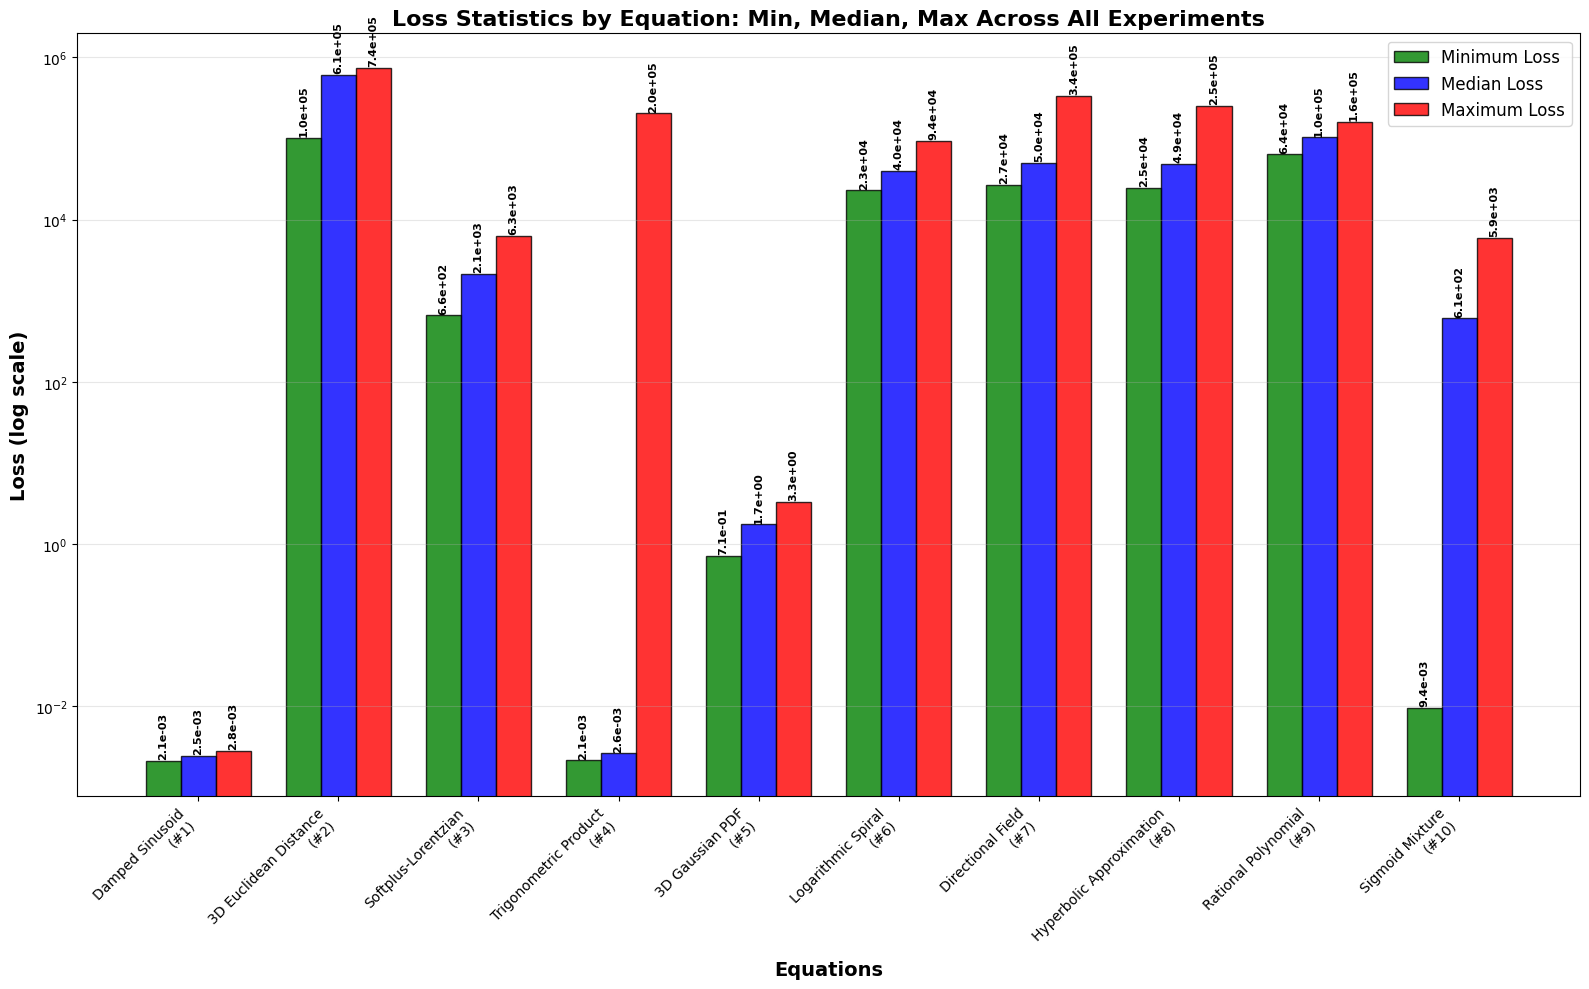


Detailed Equation Statistics (Median vs Mean Comparison):
Equation             Count  Min Loss     Median Loss  Mean Loss    Max Loss     IQR          Range Ratio 
------------------------------------------------------------------------------------------------------------------------
Damped Sinusoid      9      2.11e-03     2.46e-03     2.45e-03     2.82e-03     2.35e-04     1.3         
3D Euclidean Distance 9      1.03e+05     6.07e+05     4.38e+05     7.39e+05     4.96e+05     7.2         
Softplus-Lorentzian  9      6.56e+02     2.14e+03     2.42e+03     6.29e+03     1.74e+03     9.6         
Trigonometric Product 9      2.14e-03     2.63e-03     3.23e+04     2.03e+05     1.93e+04     94838383.1  
3D Gaussian PDF      9      7.10e-01     1.74e+00     1.83e+00     3.31e+00     1.07e+00     4.7         
Logarithmic Spiral   9      2.30e+04     3.96e+04     4.36e+04     9.36e+04     1.45e+04     4.1         
Directional Field    9      2.66e+04     5.05e+04     9.41e+04     3.37e+05 

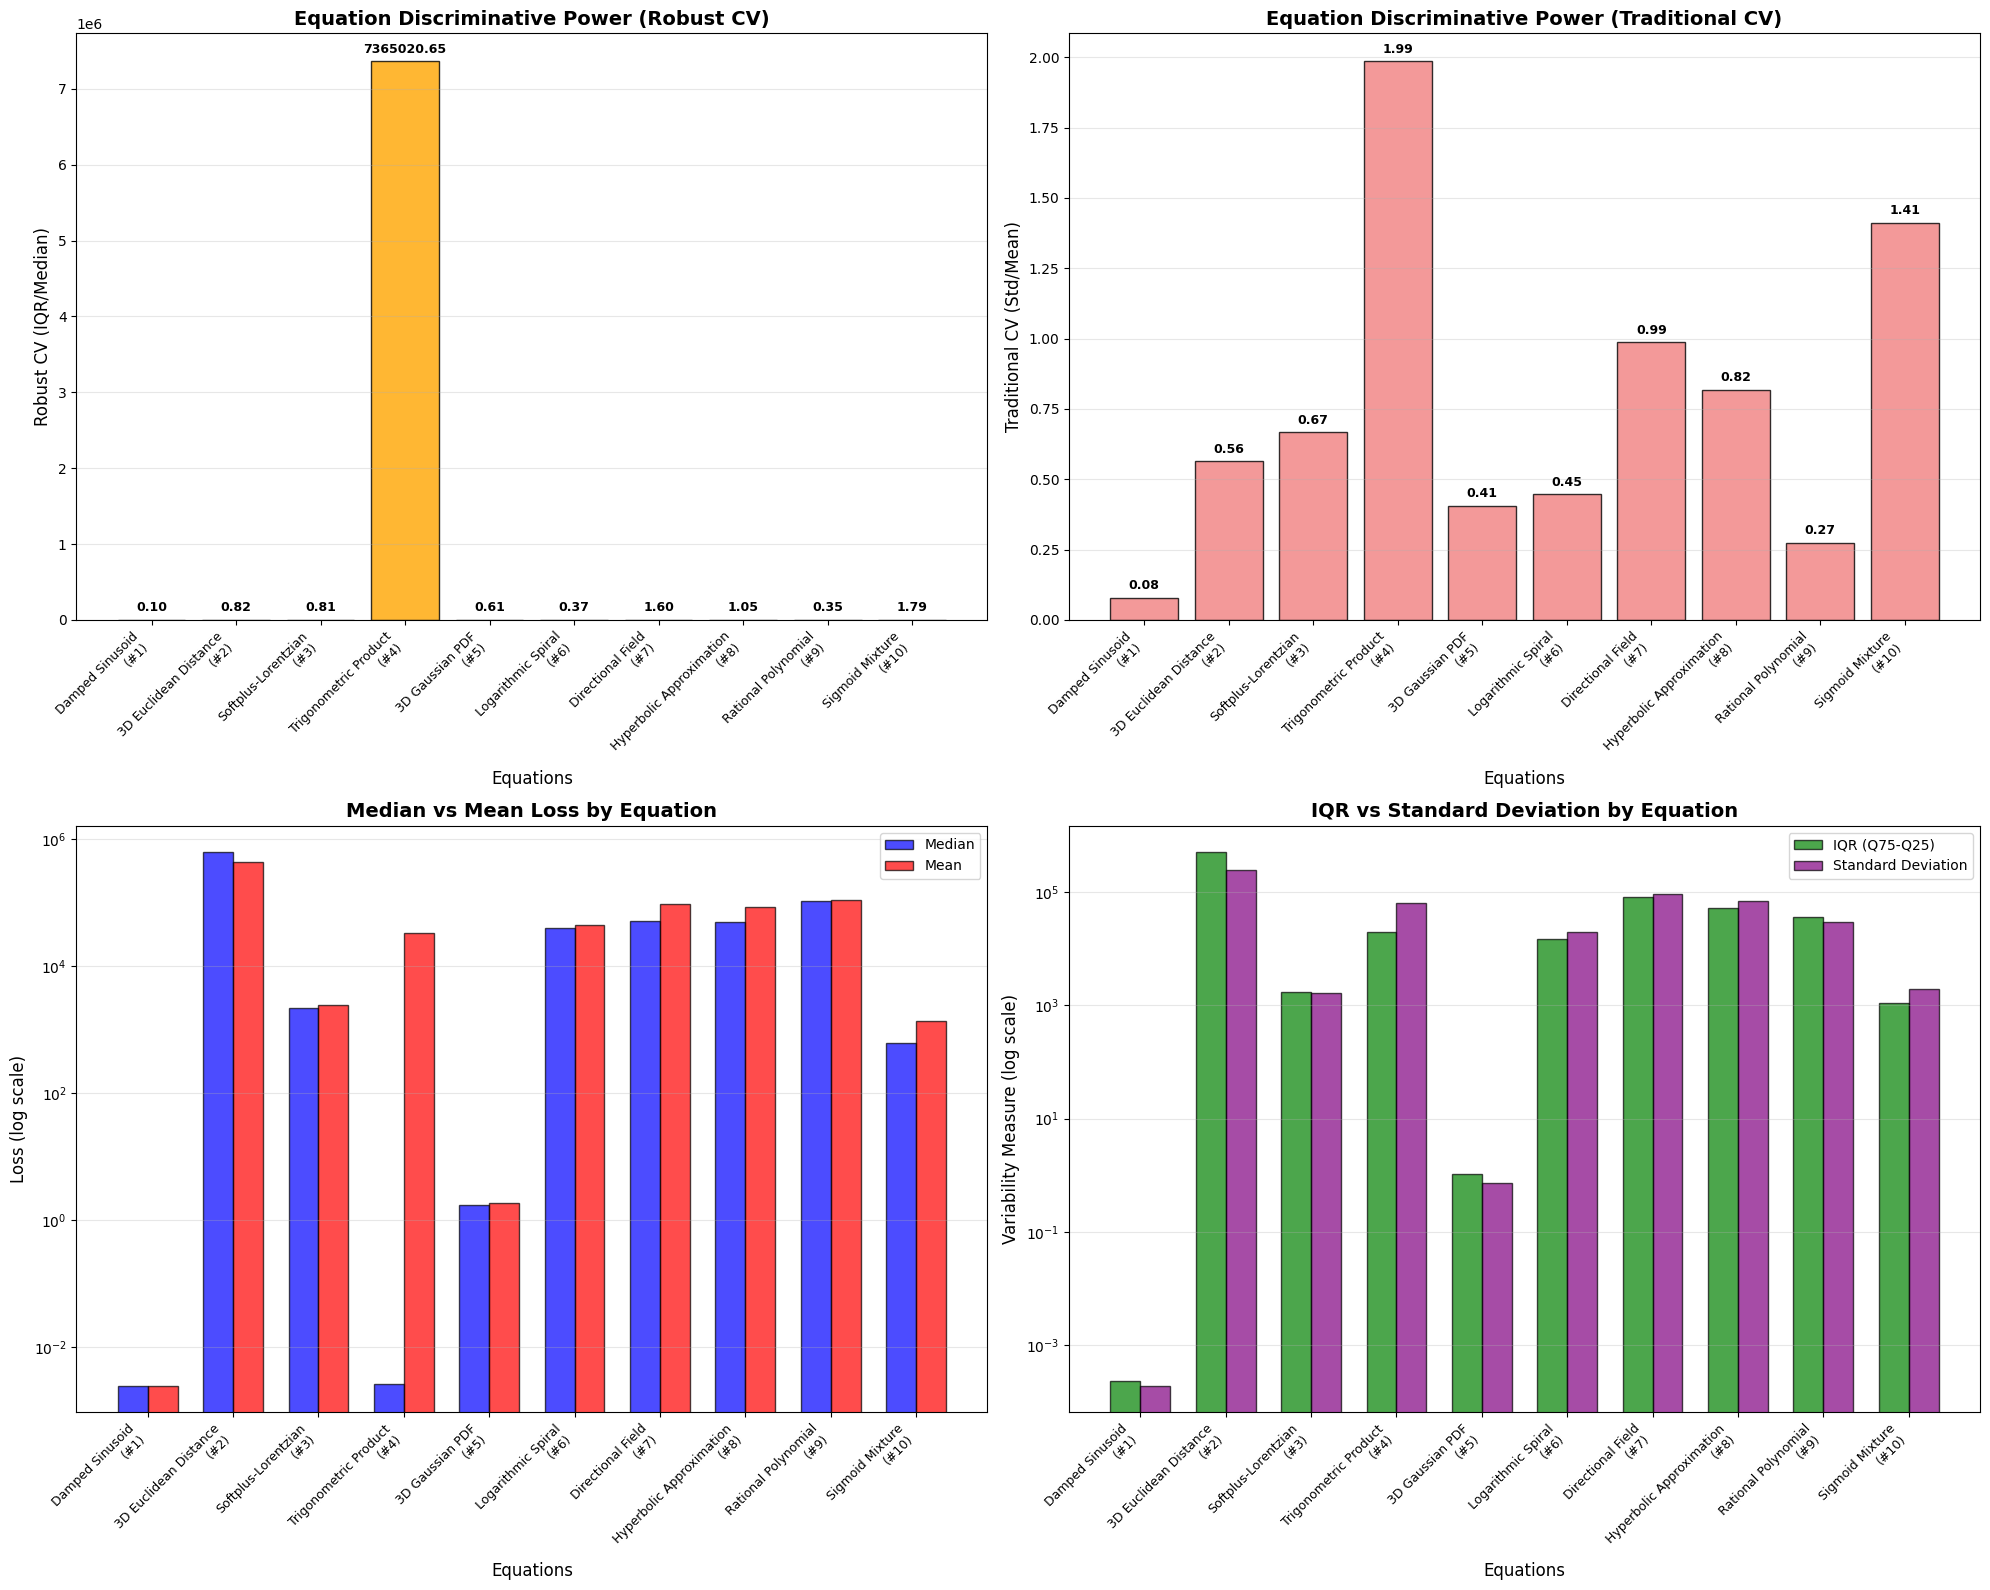


KEY INSIGHTS: MEDIAN vs MEAN ANALYSIS
Most Discriminative Equation (Robust CV): Trigonometric Product (#4) - Robust CV: 7365020.65
Most Discriminative Equation (Traditional CV): Trigonometric Product (#4) - Traditional CV: 1.99
Least Discriminative Equation (Robust CV): Damped Sinusoid (#1) - Robust CV: 0.10

Equations where Median and Mean differ significantly (indicating skewed distributions):
Equation             Median       Mean         Ratio (Mean/Median) 
----------------------------------------------------------------------
Trigonometric Product 2.63e-03     3.23e+04     12282314.73         
Directional Field    5.05e+04     9.41e+04     1.87                
Hyperbolic Approximation 4.90e+04     8.52e+04     1.74                
Sigmoid Mixture      6.05e+02     1.37e+03     2.27                

Why use Median-based analysis?
- Median is more robust to outliers than mean
- IQR is more robust to outliers than standard deviation
- Robust CV (IQR/Median) gives a better measure o

In [48]:
# Equation-wise Loss Statistics Analysis (Using Median)
print("="*100)
print("EQUATION-WISE LOSS STATISTICS ANALYSIS (MEDIAN-BASED)")
print("="*100)

import numpy as np
import matplotlib.pyplot as plt

# Calculate statistics for each equation across all experiments
equation_stats = {}
experiment_keys = ['baseline'] + list(range(8))

for eq_num in all_equations:
    losses_for_eq = []
    
    # Collect all loss values for this equation
    for exp_key in experiment_keys:
        if eq_num in exp_data[exp_key]:
            losses_for_eq.append(exp_data[exp_key][eq_num])
    
    if losses_for_eq:
        equation_stats[eq_num] = {
            'median': np.median(losses_for_eq),
            'mean': np.mean(losses_for_eq),
            'min': np.min(losses_for_eq),
            'max': np.max(losses_for_eq),
            'q25': np.percentile(losses_for_eq, 25),
            'q75': np.percentile(losses_for_eq, 75),
            'iqr': np.percentile(losses_for_eq, 75) - np.percentile(losses_for_eq, 25),
            'std': np.std(losses_for_eq),
            'count': len(losses_for_eq),
            'all_losses': losses_for_eq
        }

# Create comprehensive equation statistics plot using MEDIAN
fig, ax = plt.subplots(figsize=(16, 10))

# Prepare data for grouped bar chart
equations = sorted(equation_stats.keys())
eq_names = [equation_info[eq]['name'] if eq in equation_info else f'Eq #{eq}' for eq in equations]

medians = [equation_stats[eq]['median'] for eq in equations]
mins = [equation_stats[eq]['min'] for eq in equations]
maxs = [equation_stats[eq]['max'] for eq in equations]

# Set up bar positions
x = np.arange(len(equations))
width = 0.25

# Create grouped bars
bars1 = ax.bar(x - width, mins, width, label='Minimum Loss', color='green', alpha=0.8, edgecolor='black')
bars2 = ax.bar(x, medians, width, label='Median Loss', color='blue', alpha=0.8, edgecolor='black')
bars3 = ax.bar(x + width, maxs, width, label='Maximum Loss', color='red', alpha=0.8, edgecolor='black')

# Customize the plot
ax.set_xlabel('Equations', fontsize=14, fontweight='bold')
ax.set_ylabel('Loss (log scale)', fontsize=14, fontweight='bold')
ax.set_title('Loss Statistics by Equation: Min, Median, Max Across All Experiments', fontsize=16, fontweight='bold')
ax.set_yscale('log')
ax.set_xticks(x)
ax.set_xticklabels([f'{name}\n(#{eq})' for eq, name in zip(equations, eq_names)], 
                   rotation=45, ha='right', fontsize=10)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
def add_value_labels(bars, values, format_str='{:.1e}'):
    for bar, value in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height * 1.05,
                format_str.format(value), ha='center', va='bottom', 
                fontsize=8, fontweight='bold', rotation=90)

add_value_labels(bars1, mins)
add_value_labels(bars2, medians)
add_value_labels(bars3, maxs)

plt.tight_layout()
plt.show()

# Print detailed statistics table with both median and mean
print(f"\nDetailed Equation Statistics (Median vs Mean Comparison):")
print(f"{'Equation':<20} {'Count':<6} {'Min Loss':<12} {'Median Loss':<12} {'Mean Loss':<12} {'Max Loss':<12} {'IQR':<12} {'Range Ratio':<12}")
print("-" * 120)

for eq_num in equations:
    stats = equation_stats[eq_num]
    eq_name = equation_info[eq_num]['name'] if eq_num in equation_info else f'Eq #{eq_num}'
    range_ratio = stats['max'] / stats['min'] if stats['min'] > 0 else float('inf')
    
    print(f"{eq_name:<20} {stats['count']:<6} {stats['min']:<12.2e} {stats['median']:<12.2e} "
          f"{stats['mean']:<12.2e} {stats['max']:<12.2e} {stats['iqr']:<12.2e} {range_ratio:<12.1f}")

# Additional analysis: Equation difficulty ranking using MEDIAN-based metrics
print(f"\n" + "="*100)
print("EQUATION DIFFICULTY ANALYSIS (MEDIAN-BASED)")
print("="*100)

# Calculate robust measures of difficulty
equation_difficulty = {}
for eq_num in equations:
    stats = equation_stats[eq_num]
    # Use IQR/median as a robust measure of relative variability (similar to CV but robust)
    robust_cv = stats['iqr'] / stats['median'] if stats['median'] > 0 else 0
    # Also calculate traditional CV for comparison
    traditional_cv = stats['std'] / stats['mean'] if stats['mean'] > 0 else 0
    
    equation_difficulty[eq_num] = {
        'robust_cv': robust_cv,
        'traditional_cv': traditional_cv,
        'range_ratio': stats['max'] / stats['min'] if stats['min'] > 0 else float('inf'),
        'median_loss': stats['median'],
        'mean_loss': stats['mean'],
        'iqr': stats['iqr']
    }

# Sort by robust CV (IQR/median - more resistant to outliers)
sorted_by_robust_cv = sorted(equation_difficulty.items(), key=lambda x: x[1]['robust_cv'], reverse=True)

print(f"\nEquation Difficulty Ranking (by Robust CV = IQR/Median):")
print(f"Robust CV is less sensitive to outliers than traditional CV = std/mean")
print(f"{'Rank':<5} {'Equation':<20} {'Robust CV':<12} {'Traditional CV':<15} {'Range Ratio':<12} {'Median Loss':<12}")
print("-" * 90)

for i, (eq_num, stats) in enumerate(sorted_by_robust_cv):
    eq_name = equation_info[eq_num]['name'] if eq_num in equation_info else f'Eq #{eq_num}'
    print(f"{i+1:<5} {eq_name:<20} {stats['robust_cv']:<12.2f} {stats['traditional_cv']:<15.2f} "
          f"{stats['range_ratio']:<12.1f} {stats['median_loss']:<12.2e}")

# Create comparison plots: Median-based vs Mean-based analysis
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 16))

# Plot 1: Robust CV (IQR/Median)
robust_cv_values = [equation_difficulty[eq]['robust_cv'] for eq in equations]
bars_rcv = ax1.bar(range(len(equations)), robust_cv_values, color='orange', alpha=0.8, edgecolor='black')
ax1.set_xlabel('Equations', fontsize=12)
ax1.set_ylabel('Robust CV (IQR/Median)', fontsize=12)
ax1.set_title('Equation Discriminative Power (Robust CV)', fontsize=14, fontweight='bold')
ax1.set_xticks(range(len(equations)))
ax1.set_xticklabels([f'{eq_names[i]}\n(#{equations[i]})' for i in range(len(equations))], 
                    rotation=45, ha='right', fontsize=9)
ax1.grid(True, alpha=0.3, axis='y')

# Add robust CV values on bars
for bar, cv in zip(bars_rcv, robust_cv_values):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + max(robust_cv_values) * 0.01,
             f'{cv:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot 2: Traditional CV (Std/Mean) for comparison
traditional_cv_values = [equation_difficulty[eq]['traditional_cv'] for eq in equations]
bars_tcv = ax2.bar(range(len(equations)), traditional_cv_values, color='lightcoral', alpha=0.8, edgecolor='black')
ax2.set_xlabel('Equations', fontsize=12)
ax2.set_ylabel('Traditional CV (Std/Mean)', fontsize=12)
ax2.set_title('Equation Discriminative Power (Traditional CV)', fontsize=14, fontweight='bold')
ax2.set_xticks(range(len(equations)))
ax2.set_xticklabels([f'{eq_names[i]}\n(#{equations[i]})' for i in range(len(equations))], 
                    rotation=45, ha='right', fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

# Add traditional CV values on bars
for bar, cv in zip(bars_tcv, traditional_cv_values):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + max(traditional_cv_values) * 0.01,
             f'{cv:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot 3: Median vs Mean comparison
medians_for_plot = [equation_stats[eq]['median'] for eq in equations]
means_for_plot = [equation_stats[eq]['mean'] for eq in equations]

x_pos = np.arange(len(equations))
width = 0.35

bars_med = ax3.bar(x_pos - width/2, medians_for_plot, width, label='Median', color='blue', alpha=0.7, edgecolor='black')
bars_mean = ax3.bar(x_pos + width/2, means_for_plot, width, label='Mean', color='red', alpha=0.7, edgecolor='black')

ax3.set_xlabel('Equations', fontsize=12)
ax3.set_ylabel('Loss (log scale)', fontsize=12)
ax3.set_title('Median vs Mean Loss by Equation', fontsize=14, fontweight='bold')
ax3.set_yscale('log')
ax3.set_xticks(x_pos)
ax3.set_xticklabels([f'{eq_names[i]}\n(#{equations[i]})' for i in range(len(equations))], 
                    rotation=45, ha='right', fontsize=9)
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

# Plot 4: IQR vs Standard Deviation comparison
iqr_values = [equation_stats[eq]['iqr'] for eq in equations]
std_values = [equation_stats[eq]['std'] for eq in equations]

bars_iqr = ax4.bar(x_pos - width/2, iqr_values, width, label='IQR (Q75-Q25)', color='green', alpha=0.7, edgecolor='black')
bars_std = ax4.bar(x_pos + width/2, std_values, width, label='Standard Deviation', color='purple', alpha=0.7, edgecolor='black')

ax4.set_xlabel('Equations', fontsize=12)
ax4.set_ylabel('Variability Measure (log scale)', fontsize=12)
ax4.set_title('IQR vs Standard Deviation by Equation', fontsize=14, fontweight='bold')
ax4.set_yscale('log')
ax4.set_xticks(x_pos)
ax4.set_xticklabels([f'{eq_names[i]}\n(#{equations[i]})' for i in range(len(equations))], 
                    rotation=45, ha='right', fontsize=9)
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Summary insights comparing median vs mean approaches
print(f"\n" + "="*100)
print("KEY INSIGHTS: MEDIAN vs MEAN ANALYSIS")
print("="*100)

most_difficult_robust = sorted_by_robust_cv[0]
easiest_robust = sorted_by_robust_cv[-1]

# Compare with traditional CV ranking
sorted_by_traditional_cv = sorted(equation_difficulty.items(), key=lambda x: x[1]['traditional_cv'], reverse=True)
most_difficult_traditional = sorted_by_traditional_cv[0]

print(f"Most Discriminative Equation (Robust CV): {equation_info[most_difficult_robust[0]]['name']} (#{most_difficult_robust[0]}) - Robust CV: {most_difficult_robust[1]['robust_cv']:.2f}")
print(f"Most Discriminative Equation (Traditional CV): {equation_info[most_difficult_traditional[0]]['name']} (#{most_difficult_traditional[0]}) - Traditional CV: {most_difficult_traditional[1]['traditional_cv']:.2f}")
print(f"Least Discriminative Equation (Robust CV): {equation_info[easiest_robust[0]]['name']} (#{easiest_robust[0]}) - Robust CV: {easiest_robust[1]['robust_cv']:.2f}")

# Show cases where median and mean differ significantly
print(f"\nEquations where Median and Mean differ significantly (indicating skewed distributions):")
print(f"{'Equation':<20} {'Median':<12} {'Mean':<12} {'Ratio (Mean/Median)':<20}")
print("-" * 70)

for eq_num in equations:
    stats = equation_stats[eq_num]
    ratio = stats['mean'] / stats['median'] if stats['median'] > 0 else float('inf')
    if ratio > 1.5 or ratio < 0.67:  # Significant difference
        eq_name = equation_info[eq_num]['name'] if eq_num in equation_info else f'Eq #{eq_num}'
        print(f"{eq_name:<20} {stats['median']:<12.2e} {stats['mean']:<12.2e} {ratio:<20.2f}")

print(f"\nWhy use Median-based analysis?")
print(f"- Median is more robust to outliers than mean")
print(f"- IQR is more robust to outliers than standard deviation")
print(f"- Robust CV (IQR/Median) gives a better measure of typical variability")
print(f"- When Mean >> Median, the distribution is right-skewed (few very poor performances)")
print(f"- When Mean << Median, the distribution is left-skewed (few very good performances)")

print("\n" + "="*100)